**Data from CollegeFootballData.com**

# **Imports and Data Analysis**

In [2]:
pip install cfbd pandas numpy tqdm

In [3]:
# imports:
import matplotlib.pyplot as plt
import numpy as np
import cfbd
import pandas as pd
import numpy as np
from tqdm import tqdm
import os
from scipy import stats

In [4]:
# Getting API key from CoLab secret
from google.colab import userdata
API_KEY = userdata.get('CFBD').strip()

**Pulling Information from APIs**

In [5]:
# ----------------------------------------------------
# API Stuff
# ----------------------------------------------------

configuration = cfbd.Configuration()
configuration.access_token = API_KEY

api_client = cfbd.ApiClient(configuration)

recruiting_api = cfbd.RecruitingApi(api_client)

players_api = cfbd.PlayersApi(api_client)

games_api = cfbd.GamesApi(api_client)

# Start year and End year
START_YEAR = 2015
END_YEAR = 2025

# ----------------------------------------------------
# Getting Recruiting Data
# ----------------------------------------------------
print("Pulling recruiting data...")

recruits = []
for year in range(START_YEAR, END_YEAR + 1):
    try:
        data = recruiting_api.get_recruits(year=year)
        for p in data:
            recruits.append({
                "player_id": p.id,
                "name": p.name,
                "year": year,
                "position": p.position,
                "stars": p.stars,
                "rating": p.rating,
                "height": p.height,
                "weight": p.weight,
                "city": p.city,
                "state": p.state_province
            })
    except Exception as e:
        print(f"Error pulling {year}: {e}")

recruits_df = pd.DataFrame(recruits)
print("Recruiting data shape:", recruits_df.shape)

# ----------------------------------------------------
# Getting College Player Usage Data
# ----------------------------------------------------
print("Pulling player usage data...")

usage_rows = []

for year in range(START_YEAR, END_YEAR + 1):
    try:
        usage = players_api.get_player_usage(year=year)
        for u in usage:
            usage_rows.append({
                "player_id": u.id,
                "name": u.name,
                "season": year,
                "team": u.team,
                "position": u.position,
                "conference": u.conference,
                "usage": u.usage.overall
            })
    except Exception as e:
        print(f"Error pulling usage {year}: {e}")

usage_df = pd.DataFrame(usage_rows)
print("Usage data shape:", usage_df.shape)


Pulling recruiting data...
Recruiting data shape: (35639, 10)
Pulling player usage data...
Usage data shape: (41185, 7)


In [6]:
# ----------------------------------------------------
# Defining Starter by Usage (merging on name)
# Usage - Percentage of plays in which a player was directly involved. Includes passes, rushes, receptions, incompletions, and targets.
# ----------------------------------------------------
print("Merging dataframes...")

# Normalize names for merging
recruits_df["name_norm"] = recruits_df["name"].str.strip().str.lower()
usage_df["name_norm"] = usage_df["name"].str.strip().str.lower()

# Filter usage_df to only include players present in recruits_df
usage_df_filtered = usage_df[usage_df["name_norm"].isin(recruits_df["name_norm"])].copy()
print("Usage data shape after filtering:", usage_df_filtered.shape)

# Check how many unique players were in the filtered set
unique_players_start = usage_df_filtered["name_norm"].nunique()

print(f"Unique players available: {unique_players_start}")

# Merge recruit year into usage data based on normalized name
usage_with_year = usage_df_filtered.merge(
    recruits_df[["name_norm", "year"]],
    on="name_norm",
    how="left"
)

# Compute years since recruit
usage_with_year["years_since_recruit"] = usage_with_year["season"] - usage_with_year["year"]

# Filter to first 2 seasons
usage_first2 = usage_with_year[usage_with_year["years_since_recruit"] <= 2]

# Create data table with player names and team names
team_per_player = (
    usage_first2.groupby(["name_norm", "team"])
    .size()
    .reset_index(name="n_rows")
    .sort_values(["name_norm", "n_rows"], ascending=[True, False])
    .drop_duplicates("name_norm")[["name_norm", "team"]]
)

# Compute average usage in first 2 seasons
usage_agg = (
    usage_first2.groupby("name_norm")
    .agg(
        max_usage_first2yrs=("usage", "max"),
        position=("position", "first")
    )
    .reset_index()
)

# Grab one conference per player (most frequent)
conference_per_player = (
    usage_first2.groupby(["name_norm", "conference"])
    .size()
    .reset_index(name="n_rows")
    .sort_values(["name_norm", "n_rows"], ascending=[True, False])
    .drop_duplicates("name_norm")[["name_norm", "conference"]]
)


Merging dataframes...
Usage data shape after filtering: (20571, 8)
Unique players available: 7174


**Assigning "Starter by Year 2" label**

In [7]:
# Merge team_per_player into usage_agg to get the 'team' column
usage_agg = usage_agg.merge(team_per_player, on='name_norm', how='left')

# Merge conference_per_player into usage_agg to get the 'conference' column
usage_agg = usage_agg.merge(conference_per_player, on='name_norm', how='left')

print("Teams in usage_agg:", usage_agg['team'].notna().sum())

threshold = 0.1
usage_agg["starter_by_year2"] = (usage_agg["max_usage_first2yrs"] >= threshold).astype(int)

# Perform the merge
data = recruits_df.merge(
    usage_agg[['name_norm', 'team', 'conference', 'max_usage_first2yrs', 'starter_by_year2']],
    on="name_norm",
    how="left"
)

# Fill the missing starters (those who didn't play or didn't meet threshold)
data["starter_by_year2"] = data["starter_by_year2"].fillna(0)

# Fill the 'Unknowns' AND the 'NaNs' with your new category
data['conference'] = data['conference'].fillna('No Stats')

# Ensure your 'team' column has a corresponding label
data['team'] = data['team'].fillna('Did Not Play')

# Double-check your starter labels
## Since these players didn't meet the usage threshold,
## they should be coded as 0 (not a starter).
data['starter_by_year2'] = data['starter_by_year2'].fillna(0)

# Check if the unlabeled bar is an empty string or spaces
# We replace both '' and ' ' with "Unassigned"
data['conference'] = data['conference'].replace(['', ' '], 'Unassigned')

# Double check if there are any still lurking
print(f"Remaining unlabeled rows: {data[data['conference'] == ''].shape[0]}")

print("Teams in data:", data['team'].notna().sum())
print("Conference in data:", data['conference'].notna().sum())

print("Starter label assigned based on usage.")

Teams in usage_agg: 6458
Remaining unlabeled rows: 0
Teams in data: 35639
Conference in data: 35639
Starter label assigned based on usage.


**Looking at Distribution of Height and Weight of the raw data:**

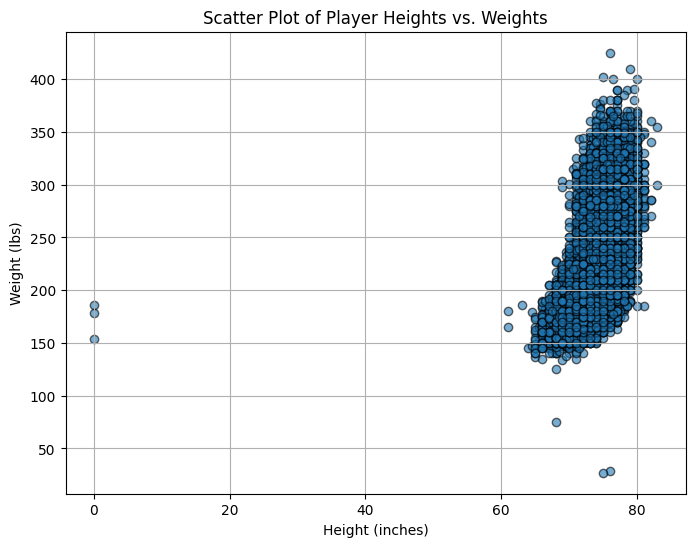

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(data["height"], data["weight"], alpha=0.6, edgecolor='k')
plt.xlabel("Height (inches)")
plt.ylabel("Weight (lbs)")
plt.title("Scatter Plot of Player Heights vs. Weights")
plt.grid(True)
plt.show()

**Getting rid of outliers:**

In [9]:
nan_count_weight = data['weight'].isnull().sum()
print(f"Number of NaN values in 'weight' column of data_no_outliers: {nan_count_weight}")
nan_count_height = data['height'].isnull().sum()
print(f"Number of NaN values in 'height' column of data_no_outliers: {nan_count_height}")

Number of NaN values in 'weight' column of data_no_outliers: 49
Number of NaN values in 'height' column of data_no_outliers: 0


In [10]:
# Select the columns to check for outliers
cols = ["height", "weight"]

# some NaNs in the weight column - replacing them with the median:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
data["weight"] = imputer.fit_transform(data[["weight"]])

# Compute z-scores
z_scores = np.abs(stats.zscore(data[cols]))

# Keep rows where all z-scores are less than threshold (e.g., 3)
data_no_outliers = data[(z_scores < 3).all(axis=1)]

print(f"Original data shape: {data.shape}")
print(f"After removing outliers: {data_no_outliers.shape}")

Original data shape: (35639, 15)
After removing outliers: (35507, 15)


There are no outliers that are starters, so dropping the outliers does not make an impact on who we consider as a starter:

In [11]:
import numpy as np
from scipy import stats

cols = ["height", "weight"]
z_scores = np.abs(stats.zscore(data[cols]))

data[(z_scores >= 3).all(axis=1) & (data["starter_by_year2"] == 1)].shape[0]

0

**Plot now without outliers:**

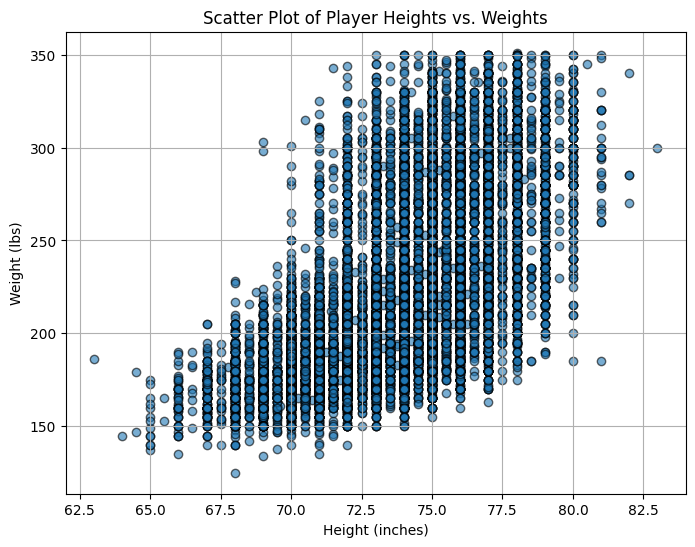

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(data_no_outliers["height"], data_no_outliers["weight"], alpha=0.6, edgecolor='k')
plt.xlabel("Height (inches)")
plt.ylabel("Weight (lbs)")
plt.title("Scatter Plot of Player Heights vs. Weights")
plt.grid(True)
plt.show()

In [13]:
# Check min and max of height and weight
data_no_outliers[["height", "weight"]].agg(["min", "max"])

,height,weight
min,63.0,125.0
max,83.0,351.0


**Number of successful starters (not filtering for repeat values here):**

In [14]:
starters = data_no_outliers[data_no_outliers["starter_by_year2"]==1]
starters.shape

(2540, 15)

In [15]:
# Mark which players are starters
unique_starters = starters.drop_duplicates(subset=['name_norm'])
unique_players = data_no_outliers.drop_duplicates(subset=['name_norm']).copy()
unique_players['is_starter'] = unique_players['name_norm'].isin(unique_starters['name_norm']).astype(int)

# Summarize counts and percentages
summary = unique_players.groupby('is_starter').agg(
    count=('name', 'count')
).reset_index()

summary['percent'] = 100 * summary['count'] / summary['count'].sum()

# Rename for clarity
summary['starter_label'] = summary['is_starter'].map({0: 'Not Starter', 1: 'Starter'})
summary = summary[['starter_label', 'count', 'percent']]

print(summary)

  starter_label  count    percent
0   Not Starter  32028  93.531525
1       Starter   2215   6.468475


/tmp/ipykernel_16257/1254688415.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


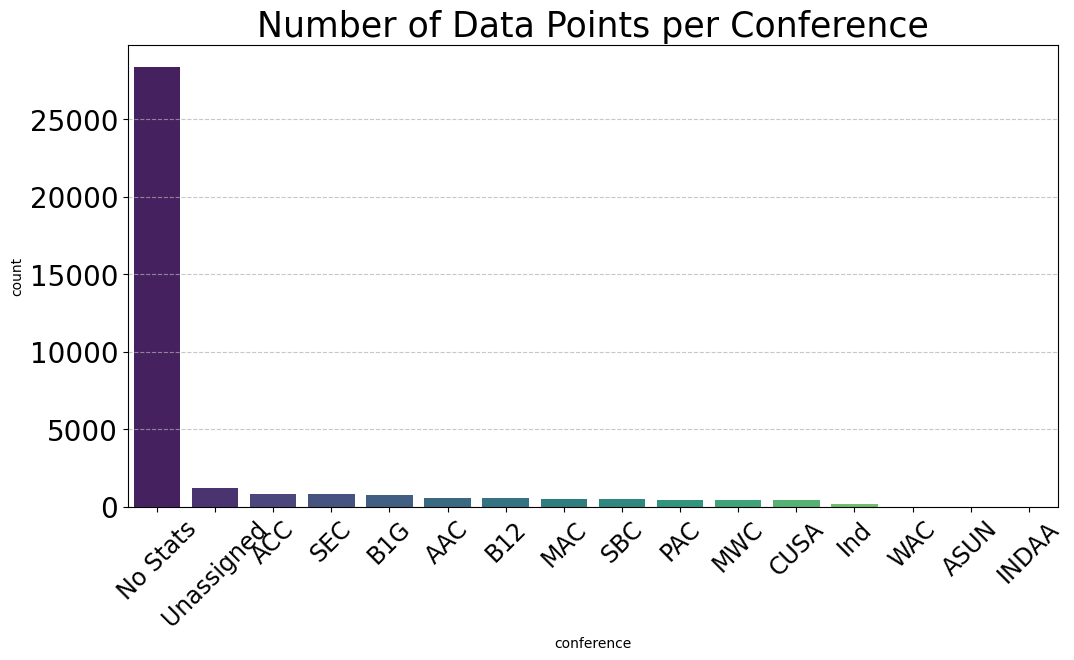

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Using countplot for categorical 'histogram'
# order=... ensures the bars are sorted from highest to lowest count
sns.countplot(
    data=data_no_outliers,
    x="conference",
    order=data_no_outliers["conference"].value_counts().index,
    palette="viridis"
)

plt.title("Number of Data Points per Conference", fontsize=25)
plt.xticks(rotation=45, fontsize = 17) # Rotates labels so they don't overlap
plt.yticks(fontsize = 20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Confirming that there are no starters assigned to the 'No Stats' conference:**

In [17]:
# Filter for No Stats conference where the starter label is 1
starters_in_no_stats = data_no_outliers[
    (data_no_outliers['conference'] == 'No Stats') &
    (data_no_outliers['starter_by_year2'] == 1)
]

print(f"Number of starters in 'No Stats' conference: {len(starters_in_no_stats)}")

starters_in_unassigned = data_no_outliers[
    (data_no_outliers['conference'] == 'Unassigned') &
    (data_no_outliers['starter_by_year2'] == 1)
]

print(f"Number of starters in 'Unassigned' conference: {len(starters_in_unassigned)}")

Number of starters in 'No Stats' conference: 0
Number of starters in 'Unassigned' conference: 511


**Looking at data without the 'No Stats' conference:**

In [18]:
# Create a new dataframe that excludes 'No Stats'
data_allStats = data_no_outliers[data_no_outliers['conference'] != 'No Stats'].copy()

# Optional: Verify it worked
print(f"Original shape: {data_no_outliers.shape}")
print(f"Cleaned shape: {data_allStats.shape}")

Original shape: (35507, 15)
Cleaned shape: (7136, 15)


count    7136.000000
mean        0.120777
std         0.138017
min         0.010000
25%         0.035000
50%         0.068000
75%         0.137000
max         0.886000
Name: max_usage_first2yrs, dtype: float64


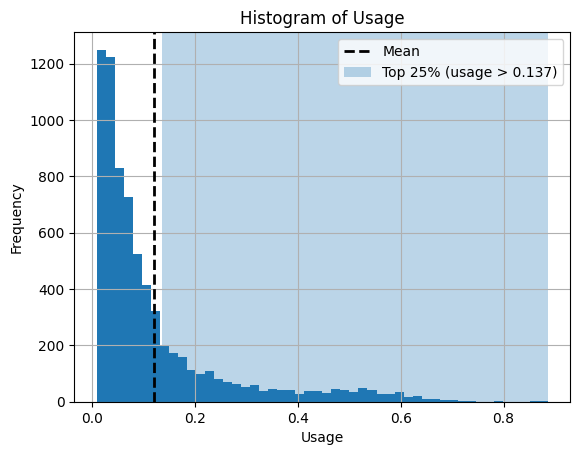

In [19]:
mean_usage = data_allStats["max_usage_first2yrs"].mean()
max_usage = data_allStats["max_usage_first2yrs"].max()

print(data_allStats["max_usage_first2yrs"].describe())
data_allStats["max_usage_first2yrs"].hist(bins=50)

plt.axvline(mean_usage, linestyle="--", linewidth=2, label="Mean", color = 'black')
plt.axvspan(0.137, max_usage, alpha=0.3, label="Top 25% (usage > 0.137)")

plt.xlabel("Usage")
plt.ylabel("Frequency")
plt.title("Histogram of Usage")

plt.legend()
plt.show()

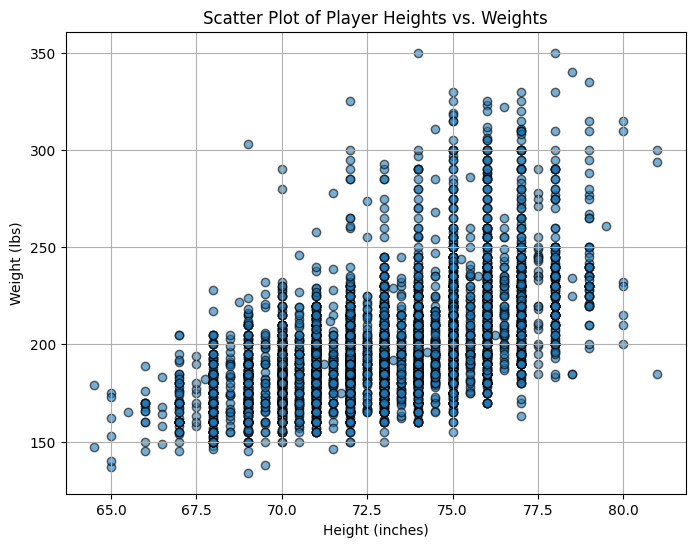

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(data_allStats["height"], data_allStats["weight"], alpha=0.6, edgecolor='k')
plt.xlabel("Height (inches)")
plt.ylabel("Weight (lbs)")
plt.title("Scatter Plot of Player Heights vs. Weights")
plt.grid(True)
plt.show()

**Looking at what the teams are in the "Unassigned" conference:**

In [21]:
# Filter for teams where the conference is blank, empty, or 'Unassigned'
# Adjust the condition if you used 'No Stats' instead
unassigned_teams = data_allStats[
    (data_allStats['conference'] == 'Unassigned')
]['team'].dropna().unique()

# Sort them alphabetically
unassigned_teams.sort()

print(f"There are {len(unassigned_teams)} unique teams in the 'Unassigned' category:")
print(unassigned_teams)


There are 159 unique teams in the 'Unassigned' category:
['Abilene Christian' 'Alabama A&M' 'Alabama State' 'Alcorn State'
 'Arizona' 'Arizona State' 'Arkansas-Pine Bluff' 'Austin Peay'
 'Ball State' 'Bethune-Cookman' 'Boise State' 'Brown' 'Bryant' 'Bucknell'
 'Buffalo' 'Cal Poly' 'California' 'Campbell' 'Central Arkansas'
 'Central Connecticut' 'Central Michigan' 'Charleston Southern'
 'Charlotte' 'Chattanooga' 'Clemson' 'Coastal Carolina' 'Colgate'
 'Colorado' 'Columbia' 'Cornell' 'Dartmouth' 'Delaware' 'Delaware State'
 'Drake' 'Duke' 'Duquesne' 'East Tennessee State' 'East Texas A&M'
 'Eastern Illinois' 'Eastern Kentucky' 'Eastern Michigan'
 'Eastern Washington' 'Elon' 'Florida' 'Florida A&M' 'Florida State'
 'Fordham' 'Furman' 'Gardner-Webb' 'Georgetown' 'Grambling' 'Hampton'
 'Harvard' "Hawai'i" 'Holy Cross' 'Houston' 'Houston Christian' 'Howard'
 'Idaho' 'Idaho State' 'Illinois' 'Illinois State' 'Incarnate Word'
 'Indiana' 'Indiana State' 'Jackson State' 'Jacksonville State'
 'J

In [22]:
#conferences of above teams excluding teams that are in conferences we are already looking at:
unique_conferences = [
    "Atlantic 10",
    "Big Sky Conference",
    "Big South",
    "Coastal Athletic Association (CAA)",
    "Ivy League",
    "Mid-Eastern Athletic Conference (MEAC)",
    "Missouri Valley Football Conference (MVFC)",
    "Northeast Conference (NEC)",
    "Ohio Valley Conference (OVC)",
    "Patriot League",
    "Pioneer Football League",
    "Southland",
    "Southern Conference (SoCon)",
    "Southern Intercollegiate Athletic Conf (SIAC)",
    "United Athletic Conference (UAC)"
]
print("Conferences contained in 'Unassigned' :" + str(unique_conferences))

Conferences contained in 'Unassigned' :['Atlantic 10', 'Big Sky Conference', 'Big South', 'Coastal Athletic Association (CAA)', 'Ivy League', 'Mid-Eastern Athletic Conference (MEAC)', 'Missouri Valley Football Conference (MVFC)', 'Northeast Conference (NEC)', 'Ohio Valley Conference (OVC)', 'Patriot League', 'Pioneer Football League', 'Southland', 'Southern Conference (SoCon)', 'Southern Intercollegiate Athletic Conf (SIAC)', 'United Athletic Conference (UAC)']


**Making a dictionary to map the teams to the already known conferences in the data. I am leaving the ones that do not correspond to an already existing conference as being 'Unassigned'.**

In [23]:
# Create the map: Only FBS conferences are tagged
fbs_conference_map = {
    # SEC
    'Alabama': 'SEC', 'LSU': 'SEC', 'Missouri': 'SEC', 'Florida': 'SEC', 'Texas': 'SEC',
    # B1G
    'Michigan': 'B1G', 'Nebraska': 'B1G', 'Illinois': 'B1G', 'Indiana': 'B1G', 'Ohio State': 'B1G', 'Penn State': 'B1G', 'Wisconsin': 'B1G',
    # ACC
    'Clemson': 'ACC', 'Florida State': 'ACC', 'Duke': 'ACC', 'Syracuse': 'ACC', 'Miami': 'ACC', 'Louisville': 'ACC', 'North Carolina': 'ACC',
    # B12
    'Arizona': 'B12', 'Arizona State': 'B12', 'Colorado': 'B12', 'Utah': 'B12', 'BYU': 'B12', 'Kansas': 'B12', 'Kansas State': 'B12',
    # AAC
    'Charlotte': 'AAC', 'Memphis': 'AAC', 'UTSA': 'AAC', 'UAB': 'AAC', 'Rice': 'AAC', 'Tulane': 'AAC', 'South Florida': 'AAC',
    # CUSA
    'Jacksonville State': 'CUSA', 'Kennesaw State': 'CUSA', 'Liberty': 'CUSA', 'Sam Houston': 'CUSA', 'UTEP': 'CUSA', 'New Mexico State': 'CUSA',
    # SBC
    'Coastal Carolina': 'SBC', 'Old Dominion': 'SBC', 'Appalachian State': 'SBC', 'Georgia State': 'SBC', 'James Madison': 'SBC', 'Texas State': 'SBC',
    # MAC
    'Ball State': 'MAC', 'Buffalo': 'MAC', 'Central Michigan': 'MAC', 'Eastern Michigan': 'MAC', 'Kent State': 'MAC', 'Miami (OH)': 'MAC', 'Northern Illinois': 'MAC', 'Ohio': 'MAC', 'Toledo': 'MAC',
    # MWC
    'Boise State': 'MWC', "Hawai'i": 'MWC', 'Colorado State': 'MWC', 'Fresno State': 'MWC', 'San Diego State': 'MWC', 'UNLV': 'MWC'
}
### For all data:
# 1. Fill FBS conferences
data_no_outliers['conference'] = data_no_outliers['conference'].fillna(data_no_outliers['team'].map(fbs_conference_map))

# 2. Everything remaining with a team name gets 'Unassigned'
# We use .where() to only fill where conference is still NaN but team exists
data_no_outliers['conference'] = data_no_outliers['conference'].fillna(data_no_outliers['team'].where(data_no_outliers['team'].isna(), 'Unassigned'))

# 3. Everything without a team name gets 'No Stats'
data_no_outliers['conference'] = data_no_outliers['conference'].fillna('No Stats')

### For data - 'No Stats' conference
# 1. Fill FBS conferences
data_allStats['conference'] = data_allStats['conference'].fillna(data_allStats['team'].map(fbs_conference_map))

# 2. Everything remaining with a team name gets 'Unassigned'
# We use .where() to only fill where conference is still NaN but team exists
data_allStats['conference'] = data_allStats['conference'].fillna(data_allStats['team'].where(data_allStats['team'].isna(), 'Unassigned'))

# 3. Everything without a team name gets 'No Stats'
data_allStats['conference'] = data_allStats['conference'].fillna('No Stats')

/tmp/ipykernel_16257/2847348501.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_no_outliers['conference'] = data_no_outliers['conference'].fillna(data_no_outliers['team'].map(fbs_conference_map))
/tmp/ipykernel_16257/2847348501.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_no_outliers['conference'] = data_no_outliers['conference'].fillna(data_no_outliers['team'].where(data_no_outliers['team'].isna(), 'Unassigned'))
/tmp/ipykernel_16257/2847348501.py:31: SettingWithCopyWarning: 
A value

In [24]:
print("Are there any 'Unknown' strings left?", (data_allStats['conference'] == 'Unknown').sum())
print("Are there any NaNs left?", data_allStats['conference'].isna().sum())

Are there any 'Unknown' strings left? 0
Are there any NaNs left? 0


In [25]:

print(f"Total rows in dataframe: {len(data_allStats)}")
print(f"NaNs in 'team' column: {data_allStats['team'].isna().sum()}")
print(f"'Did Not Play' in 'team' column: {(data_allStats['team']=='Did Not Play').sum()}")

Total rows in dataframe: 7136
NaNs in 'team' column: 0
'Did Not Play' in 'team' column: 0


**Checking if any remaining 'unknown' conferences:**

In [26]:
# Check if anything is still missing
remaining_unknowns = data_no_outliers[data_no_outliers['conference'].isna()]['team'].unique()
print("Teams still without a conference:", remaining_unknowns)

Teams still without a conference: []


In [27]:
#looking at what are the conferences in the data with all teams assigned to a conference
data_allStats["conference"].unique()

array(['PAC', 'SEC', 'ACC', 'AAC', 'B12', 'Ind', 'B1G', 'Unassigned',
       'SBC', 'MWC', 'CUSA', 'MAC', 'INDAA', 'WAC', 'ASUN'], dtype=object)

Making sure that players in the No Stats conference were not assigned to a team:

In [28]:
# Reassign the dataframe to include only known conferences
data_known_teams = data_no_outliers[data_no_outliers["conference"] == 'No Stats']

# Verify the drop
print(data_known_teams["team"].unique())

['Did Not Play']


**Re-looking at counts per conference without the "No Stats" conference:**



/tmp/ipykernel_16257/1724057240.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


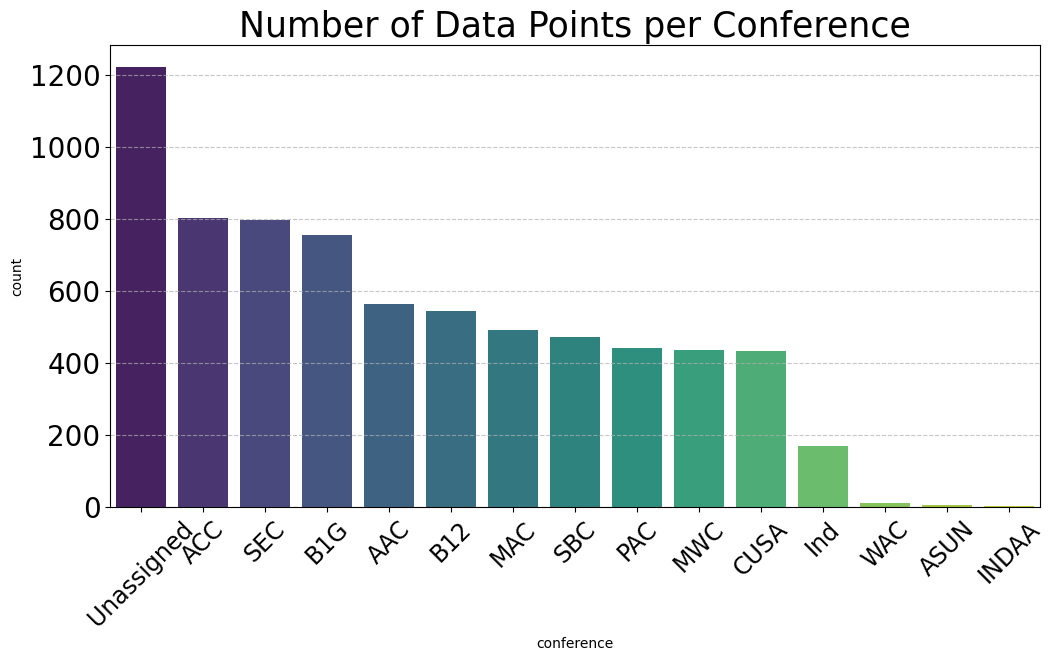

In [29]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=data_allStats,
    x="conference",
    order=data_allStats["conference"].value_counts().index,
    palette="viridis"
)

plt.title("Number of Data Points per Conference", fontsize = 25)
plt.xticks(rotation=45, fontsize = 17)
plt.yticks(fontsize = 20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Looking at distribution of starters in this dataset:**

In [30]:
starters = data_allStats[data_allStats["starter_by_year2"]==1]
starters.shape
# Mark which players are starters
unique_starters = starters.drop_duplicates(subset=['name_norm'])
unique_players = data_allStats.drop_duplicates(subset=['name_norm']).copy()
unique_players['is_starter'] = unique_players['name_norm'].isin(unique_starters['name_norm']).astype(int)

# Summarize counts and percentages
summary = unique_players.groupby('is_starter').agg(
    count=('name', 'count')
).reset_index()

summary['percent'] = 100 * summary['count'] / summary['count'].sum()

# Rename for clarity
summary['starter_label'] = summary['is_starter'].map({0: 'Not Starter', 1: 'Starter'})
summary = summary[['starter_label', 'count', 'percent']]

print(summary)

  starter_label  count    percent
0   Not Starter   4240  65.685515
1       Starter   2215  34.314485


I think we may want to use the data_allStats going forward because it would be more interesting to look at players who did end up on a team, and the 'No Stats' conference was full of non starters that did not have a team or conference assigned to them so I assume the never played anywhere. And as we can see above, the data_allStats seems to have a pretty good split between starters and non-starters (the data_no_outliers has a 94/6 split)

**Comparing Starters vs Non-Starters across conferences**

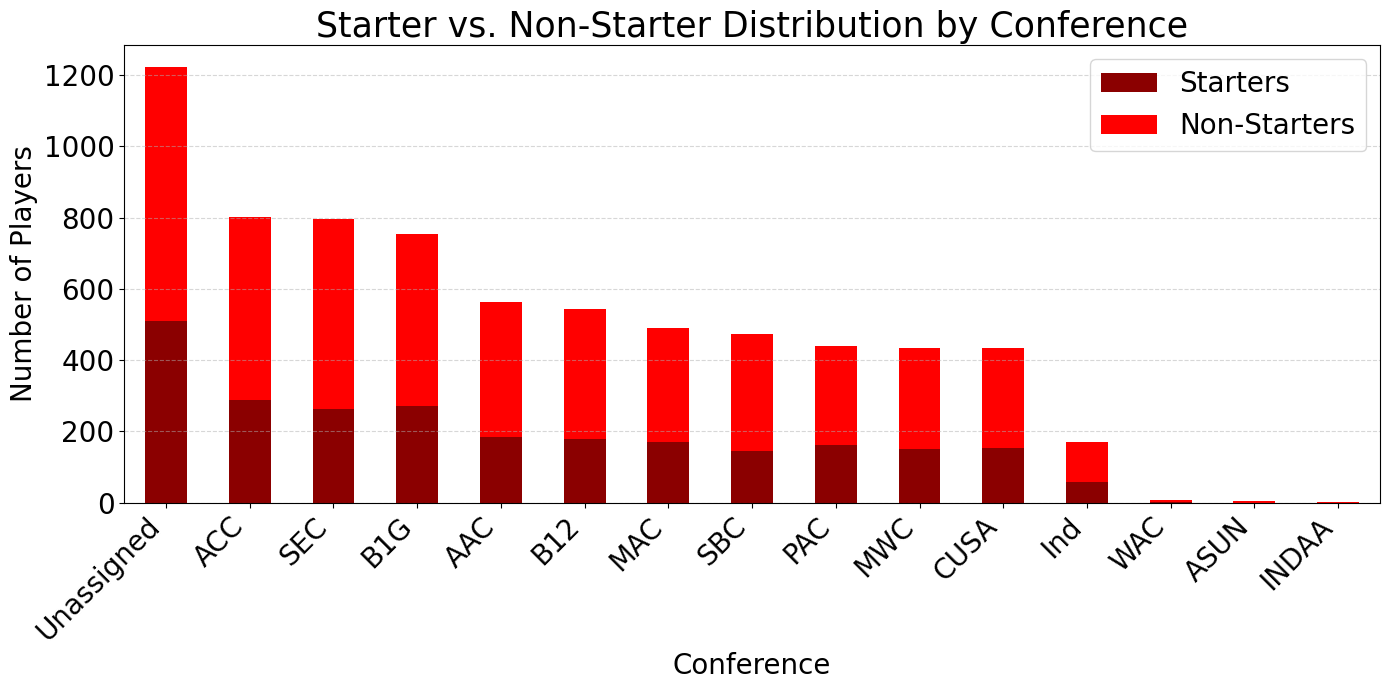

In [31]:
import matplotlib.pyplot as plt

# 1. Aggregate the data
# Calculate counts per conference
summary_df = data_allStats.groupby('conference').agg(
    Total_Starters=('starter_by_year2', 'sum'),
    Total_Players=('starter_by_year2', 'count')
)

# 2. Calculate Non-Starters
summary_df['Non_Starters'] = summary_df['Total_Players'] - summary_df['Total_Starters']

# 3. Sort by Total_Players
summary_df = summary_df.sort_values('Total_Players', ascending=False)

# 4. Prepare for plotting
# CHANGE: Put 'Total_Starters' first so it becomes the bottom layer
plot_df = summary_df[['Total_Starters', 'Non_Starters']]

# 5. Plot
# Using a contrasting color scheme (e.g., Blue for starters, Light Gray for non-starters)
ax = plot_df.plot(kind='bar', stacked=True, figsize=(14, 7), color=['darkred', 'red'])

plt.title("Starter vs. Non-Starter Distribution by Conference", fontsize= 25)
plt.xlabel("Conference", fontsize= 20)
plt.ylabel("Number of Players", fontsize= 20)
plt.xticks(rotation=45, ha='right', fontsize= 20)
plt.yticks(fontsize= 20)
plt.legend(["Starters", "Non-Starters"], fontsize= 20) # Legend updated
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Looking at positions in conferences:**

**Position Labels**
| Abbreviation | Full Name / Description    | Notes on Usage                                                                                            |
| ------------ | -------------------------- | --------------------------------------------------------------------------------------------------------- |
| **APB**      | All-Purpose Back           | Versatile offensive back who can run, catch, and return kicks. Similar to DUAL/ATH but more specific.     |
| **ATH**      | Athlete                    | Versatile athlete; could play multiple positions (offense or defense). Often a high school recruit label. |
| **CB**       | Cornerback                 | Defensive back covering receivers.                                                                        |
| **DL**       | Defensive Lineman          | Generic defensive line position; could be DE or DT.                                                       |
| **DT**       | Defensive Tackle           | Interior defensive line.                                                                                  |
| **DUAL**     | Dual-Threat                | Usually QB or RB who can contribute in multiple ways. Can also indicate multi-position athlete.           |
| **EDGE**     | Edge Rusher                | Defensive end or outside linebacker primarily responsible for rushing the passer.                         |
| **FB**       | Fullback                   | Offensive back primarily for blocking and short-yardage plays.                                            |
| **ILB**      | Inside Linebacker          | Central linebacker in a 3- or 4- linebacker defense.                                                      |
| **IOL**      | Interior Offensive Lineman | Offensive guard or center.                                                                                |
| **K**        | Kicker                     | Special teams position.                                                                                   |
| **LB**       | Linebacker                 | General linebacker (could be inside or outside).                                                          |
| **LS**       | Long Snapper               | Special teams player who snaps for punts/field goals.                                                     |
| **OC**       | Offensive Center           | Center on the offensive line.                                                                             |
| **OG**       | Offensive Guard            | Offensive lineman.                                                                                        |
| **OLB**      | Outside Linebacker         | Outside linebacker, often tasked with coverage or rushing the passer.                                     |
| **OT**       | Offensive Tackle           | Offensive line edge protector.                                                                            |
| **P**        | Punter                     | Special teams punter.                                                                                     |
| **PRO**      | Pro-Style QB / Player      | Could be a QB, or a player labeled as “pro-style” in recruiting databases.   |
| **QB**       | Quarterback                | Standard offensive leader.                                                                                |
| **RB**       | Running Back               | Standard offensive ball carrier.                                                                          |
| **RET**      | Return Specialist          | Focused on kick/punt returns. May have limited overall usage.                                             |
| **S**        | Safety                     | Defensive back, deep coverage.                                                                            |
| **SDE**      | Strong-side Defensive End  | Defensive end on the strong side of formation.                                                            |
| **TE**       | Tight End                  | Offensive lineman/receiver hybrid.                                                                        |
| **WDE**      | Weak-side Defensive End    | Defensive end on the weak side of formation.                                                              |
| **WR**       | Wide Receiver              | Standard offensive pass-catcher.                                                                          |


**looking at number of data points per position across all conferences**

In [32]:
position_table = pd.crosstab(data_allStats['conference'], data_allStats['position']).fillna(0)

styled_table = position_table.style.set_table_attributes(
    'style="display: inline-block; max-height: 400px; overflow-y: auto;"'
)

display(styled_table)

position,APB,ATH,CB,DL,DT,DUAL,EDGE,FB,ILB,IOL,K,LB,LS,OC,OG,OLB,OT,P,PRO,QB,RB,S,SDE,TE,WDE,WR
conference,,,,,,,,,,,,,,,,,,,,,,,,,,
AAC,14,66,9,4,7,26,3,1,4,1,0,3,0,1,2,6,3,1,37,33,92,11,5,49,3,182
ACC,16,78,16,5,3,30,5,1,3,0,0,3,0,0,3,4,14,1,37,52,156,15,9,88,4,259
ASUN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,0,0,2
B12,11,55,9,3,3,23,1,2,4,0,0,7,1,2,1,2,5,0,22,37,108,12,2,57,2,174
B1G,14,63,9,1,4,24,2,4,6,0,1,4,2,2,1,7,8,1,47,58,149,9,4,90,5,239
CUSA,12,42,12,5,3,19,1,3,5,1,0,2,0,0,3,5,7,1,32,24,76,8,4,36,1,131
INDAA,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Ind,7,19,3,0,0,8,0,0,5,0,0,0,0,0,1,1,0,0,14,12,32,1,1,21,0,44
MAC,14,47,16,1,4,18,2,1,6,1,0,1,0,1,6,3,6,0,38,27,95,4,3,45,2,150


**Box plots across interesting conferences for a handful of positions that are ~equally plentiful across all conferences**

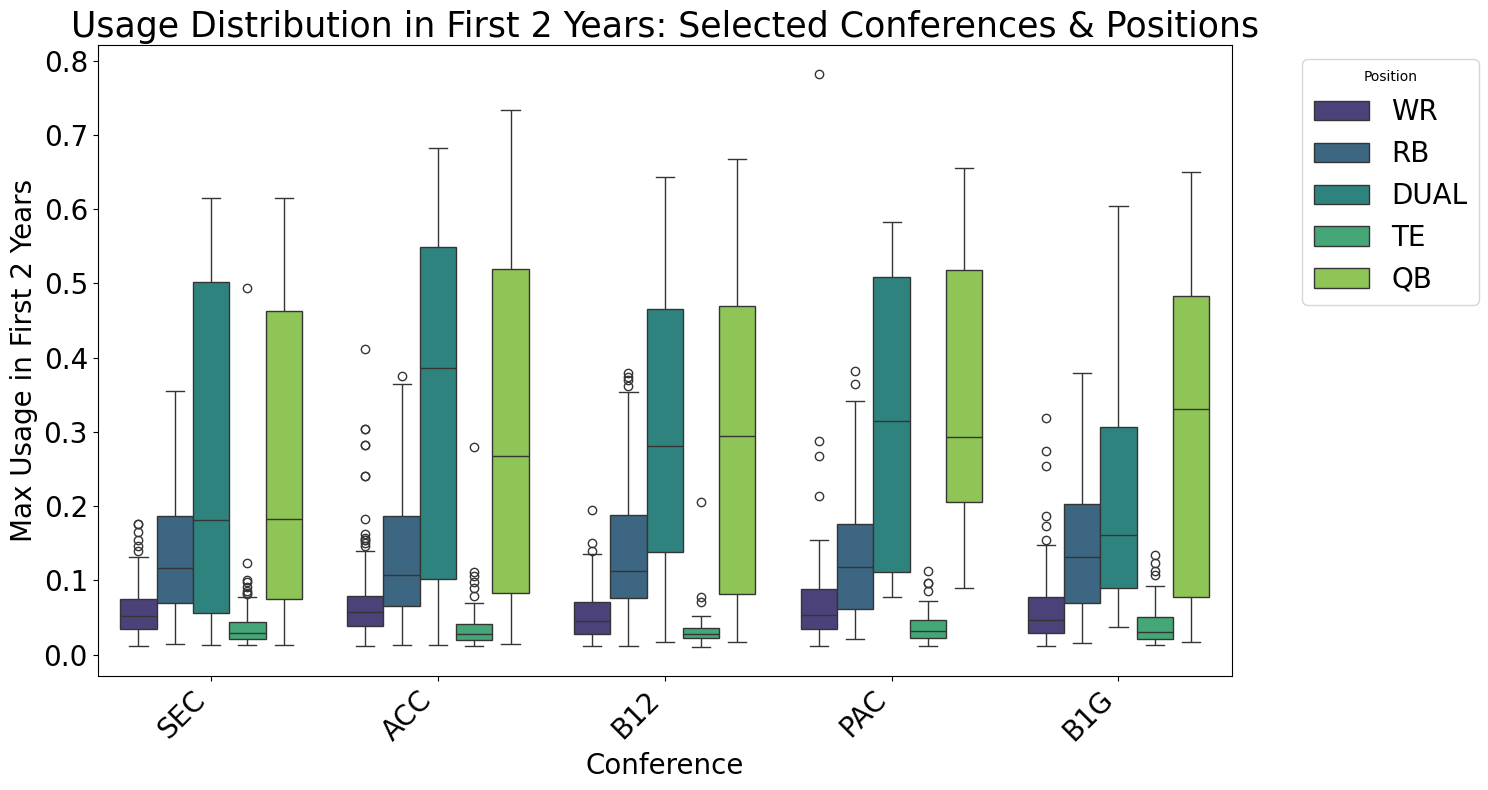

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define conference and position filters
top_conferences = ['SEC', 'ACC', 'B12', 'PAC', 'B1G']
target_positions = ['QB', 'WR', 'RB', 'TE', 'DUAL']

# Filter data_allStats
plot_df = data_allStats[
    (data_allStats['conference'].isin(top_conferences)) &
    (data_allStats['position'].isin(target_positions))
].copy()

# Create the boxplot
plt.figure(figsize=(15, 8))
sns.boxplot(
    x='conference',
    y='max_usage_first2yrs',
    hue='position',
    data=plot_df,
    order=top_conferences,
    palette='viridis'
)

# Add titles and labels
plt.title('Usage Distribution in First 2 Years: Selected Conferences & Positions', fontsize= 25)
plt.xlabel('Conference', fontsize= 20)
plt.ylabel('Max Usage in First 2 Years', fontsize= 20)
plt.xticks(rotation=45, ha='right', fontsize= 20)
plt.yticks(fontsize= 20)
plt.legend(title='Position', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize= 20)
plt.tight_layout()
plt.show()

**Creating rating_diff feature:** The goal of this feature will be to add a feature to give insights into how an individual player ranks among others at the same position.

In [34]:
# Calculate the mean rating for each position
position_means = data_allStats.groupby('position')['rating'].transform('mean')

# Create the new feature
data_allStats['rating_diff'] = data_allStats['rating'] - position_means

**Final shape check**

In [35]:
data_allStats.shape

(7136, 16)

saving off the raw data:

In [36]:
import joblib
from google.colab import drive
drive.mount('/content/drive')

data_allStats.to_csv("/content/drive/MyDrive/CS 141/all_data.csv", index=False)

Mounted at /content/drive


# **Baseline Model "Star Power"**

Baseline Accuracy: 0.607
Baseline ROC AUC: 0.533

Classification Report (Baseline):
              precision    recall  f1-score   support

         0.0       0.65      0.82      0.72      1351
         1.0       0.44      0.25      0.32       790

    accuracy                           0.61      2141
   macro avg       0.55      0.53      0.52      2141
weighted avg       0.57      0.61      0.57      2141



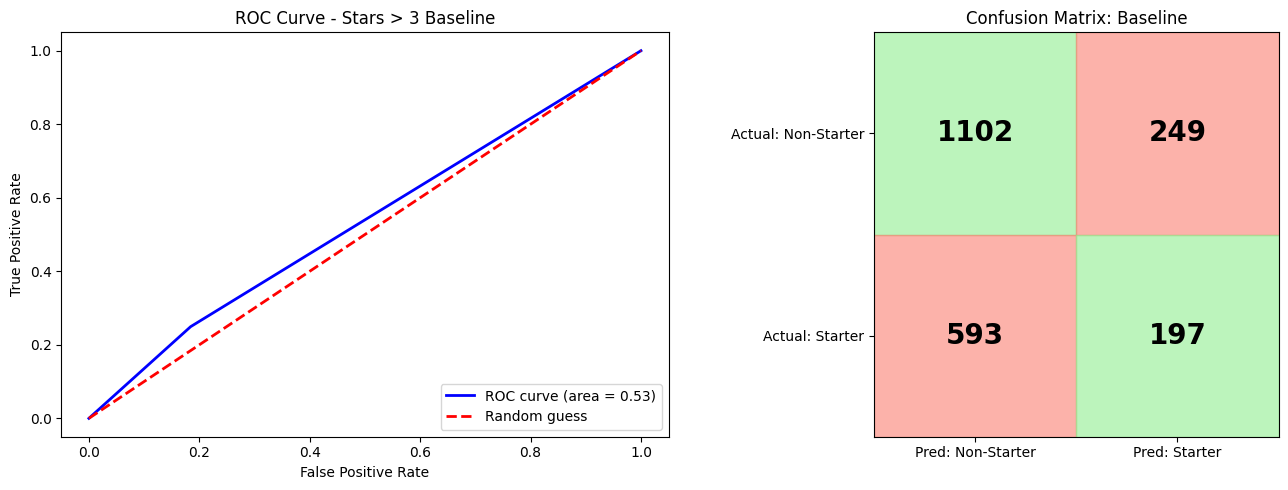

In [37]:
# -----------------------------
# Baseline Model: Stars > 3
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report

# Prepare Data
model_df = data_allStats.dropna(subset=["starter_by_year2"]).copy()
X = model_df[["stars", "rating", "height", "weight"]]
y = model_df["starter_by_year2"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Apply the Simple Rule
# If stars are 4 or 5, predict Starter (1). Otherwise, Non-Starter (0).
y_pred_baseline = (X_test['stars'] > 3).astype(int)

# Calculate Metrics
acc = accuracy_score(y_test, y_pred_baseline)
fpr, tpr, _ = roc_curve(y_test, y_pred_baseline)
roc_auc = auc(fpr, tpr)
cm = confusion_matrix(y_test, y_pred_baseline)

print(f"Baseline Accuracy: {acc:.3f}")
print(f"Baseline ROC AUC: {roc_auc:.3f}")
print("\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred_baseline))

# -----------------------------

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot ROC
ax1.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random guess')
ax1.set_title('ROC Curve - Stars > 3 Baseline')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc="lower right")

# Plot Confusion Matrix
colors = [['lightgreen', 'salmon'], ['salmon', 'lightgreen']]
ax2.imshow(np.zeros((2, 2)), alpha=0)

for i in range(2):
    for j in range(2):
        ax2.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=colors[i][j], alpha=0.6))
        ax2.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=20, fontweight='bold')

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Pred: Non-Starter', 'Pred: Starter'])
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Actual: Non-Starter', 'Actual: Starter'])
ax2.set_title("Confusion Matrix: Baseline")

plt.tight_layout()
plt.show()

# **Logistic Regression Model**

**Looking at Variance Inflation Factors among tye quantitative features**

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
cols_to_drop = ["starter_by_year2",
    "name",
    "name_norm",
    "team",
    "hometown",
    "state",
    "city",
    "school",
    "player_id",
    "max_usage_first2yrs",
    "stars"
]
X = data_allStats.drop(columns=['starter_by_year2'] + cols_to_drop, errors='ignore')
X = pd.get_dummies(X, drop_first=True)

quant_features = ['rating', 'height', 'weight', 'rating_diff']
# Scale the data first
scaler = StandardScaler()
X_subset_scaled = scaler.fit_transform(X[quant_features].dropna())

# Re-run VIF on the SCALED data
vif_data = pd.DataFrame()
vif_data["feature"] = quant_features
vif_data["VIF"] = [variance_inflation_factor(X_subset_scaled, i) for i in range(X_subset_scaled.shape[1])]
print(vif_data)

       feature        VIF
0       rating  26.668334
1       height   1.581817
2       weight   1.615639
3  rating_diff  26.652942


**Plotting the VIF score for all quantitative features**

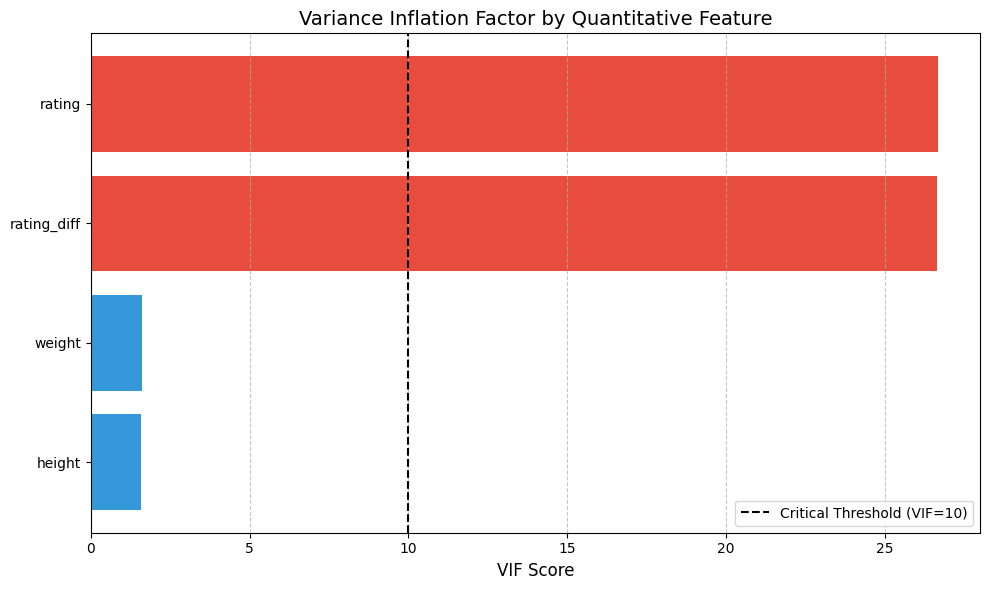

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Your VIF results
vif_results = pd.DataFrame({
    'feature': ['rating', 'rating_diff', 'height', 'weight'],
    'VIF': [26.67, 26.65, 1.58, 1.62]
})

# Sort for better readability
vif_results = vif_results.sort_values(by='VIF', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(vif_results['feature'], vif_results['VIF'], color=['#3498db', '#3498db', '#e74c3c', '#e74c3c'])

# Add threshold line at VIF = 10
plt.axvline(x=10, color='black', linestyle='--', label='Critical Threshold (VIF=10)')

# Plotting details
plt.title('Variance Inflation Factor by Quantitative Feature', fontsize=14)
plt.xlabel('VIF Score', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()



**A/B testing to see if I should remove 'rating' or 'rating_diff'**

In [40]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.model_selection import train_test_split

def evaluate_feature_set(features_to_use, X_train_full, X_test_full, y_train, y_test):
    # 1. Subset the data
    X_train_sub = X_train_full[features_to_use]
    X_test_sub = X_test_full[features_to_use]

    # 2. Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sub)
    X_test_scaled = scaler.transform(X_test_sub)

    # 3. Train
    model = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)

    # 4. Predict
    probs = model.predict_proba(X_test_scaled)[:, 1]
    return roc_auc_score(y_test, probs)

# Redefine X, y, and split for this specific A/B testing context
cols_to_drop = ["starter_by_year2",
    "name",
    "name_norm",
    "team",
    "hometown",
    "state",
    "city",
    "school",
    "player_id",
    "max_usage_first2yrs",
    "stars"
]
X = data_allStats.drop(columns=['starter_by_year2'] + cols_to_drop, errors='ignore')
X = pd.get_dummies(X, drop_first=True)
y = data_allStats['starter_by_year2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Define your base features (the ones you are keeping)
base_features = ['height', 'weight']

# A/B Test
auc_with_rating = evaluate_feature_set(base_features + ['rating'], X_train, X_test, y_train, y_test)
auc_with_diff = evaluate_feature_set(base_features + ['rating_diff'], X_train, X_test, y_train, y_test)

print(f"ROC AUC with 'rating': {auc_with_rating:.4f}")
print(f"ROC AUC with 'rating_diff': {auc_with_diff:.4f}")

ROC AUC with 'rating': 0.5906
ROC AUC with 'rating_diff': 0.5933


^ rating and rating_diff are highly correlated -> remove one -> going to remove 'rating' since that has the lower result in the A/B testing

**Now logistic regression witout 'rating':**

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

features = [
    "position",
    "height",
    "weight",
    "conference",
    "rating_diff"
]

# Identify columns to drop
cols_to_drop = ["starter_by_year2",
    "name",
    "name_norm",
    "team",
    "hometown",
    "state",
    "city",
    "school",
    "player_id",
    "max_usage_first2yrs",
    "stars",
    "rating"
]

# Create X and y
X = data_allStats.drop(columns=['starter_by_year2'] + cols_to_drop, errors='ignore')
y = data_allStats['starter_by_year2']


# Ecode and split for train/test
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training the model
log_model = LogisticRegression(
    solver = 'liblinear',
    class_weight='balanced',
    max_iter=500, # Reduced iterations to save time
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

# Results
print("Model trained successfully!")
#print(classification_report(y_test, log_model.predict(X_test_scaled)))

# evaluating the model
print("Test accuracy:", log_model.score(X_test_scaled, y_test))

y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC: {roc_auc:.3f}")

Model trained successfully!
Test accuracy: 0.7090144792153199
ROC AUC: 0.785


**looking again at VIF again:**

In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

quant_features = ['height', 'weight', 'rating_diff']
# Scale the data first
scaler = StandardScaler()
X_subset_scaled = scaler.fit_transform(X[quant_features].dropna())

# Re-run VIF on the SCALED data
vif_data = pd.DataFrame()
vif_data["feature"] = quant_features
vif_data["VIF"] = [variance_inflation_factor(X_subset_scaled, i) for i in range(X_subset_scaled.shape[1])]
print(vif_data)

       feature       VIF
0       height  1.504512
1       weight  1.502627
2  rating_diff  1.016825


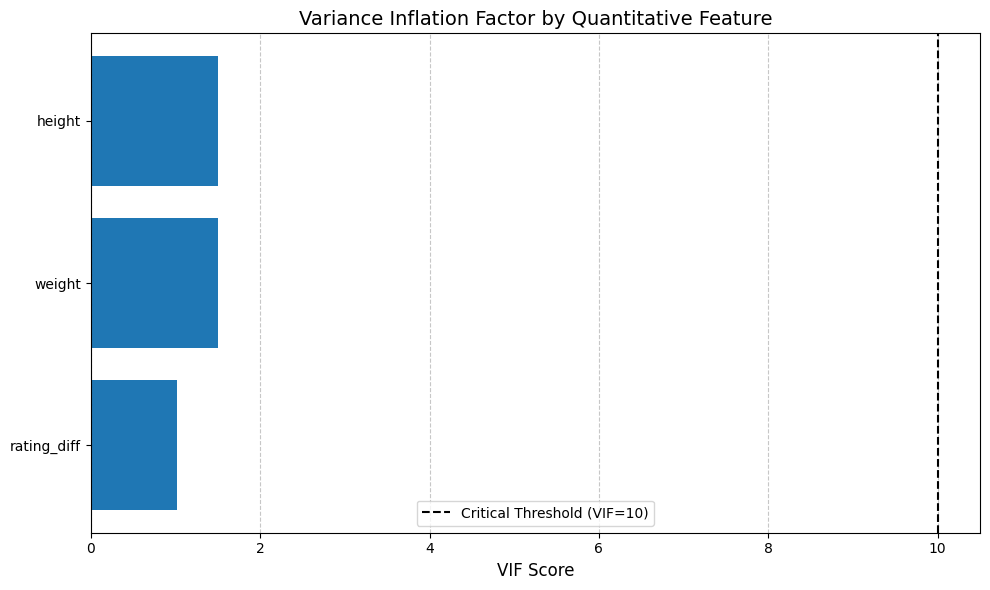

In [43]:
# New VIF results
vif_results = pd.DataFrame({
    'feature': ['rating_diff', 'height', 'weight'],
    'VIF': [1.016825, 1.504512, 1.502627]
})

# Sort for better readability
vif_results = vif_results.sort_values(by='VIF', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(vif_results['feature'], vif_results['VIF'])#, color=['#3498db', '#3498db', '#e74c3c'])

# Add threshold line at VIF = 10
plt.axvline(x=10, color='black', linestyle='--', label='Critical Threshold (VIF=10)')

# Styling
plt.title('Variance Inflation Factor by Quantitative Feature', fontsize=14)
plt.xlabel('VIF Score', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

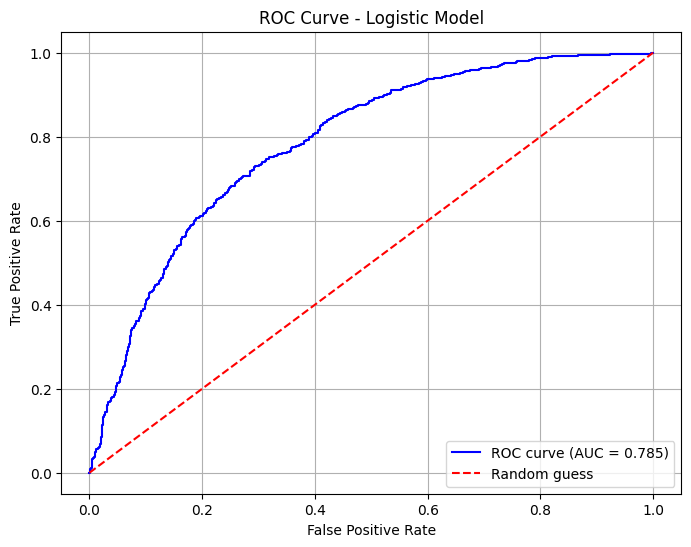

In [44]:
# plotting ROC:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_probs = log_model.predict_proba(X_test_scaled)[:, 1]  # probability of starter_by_year2 = 1

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Compute AUC
roc_auc = roc_auc_score(y_test, y_probs)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Looking at precision vs recall vs F1 and tradeoff:**

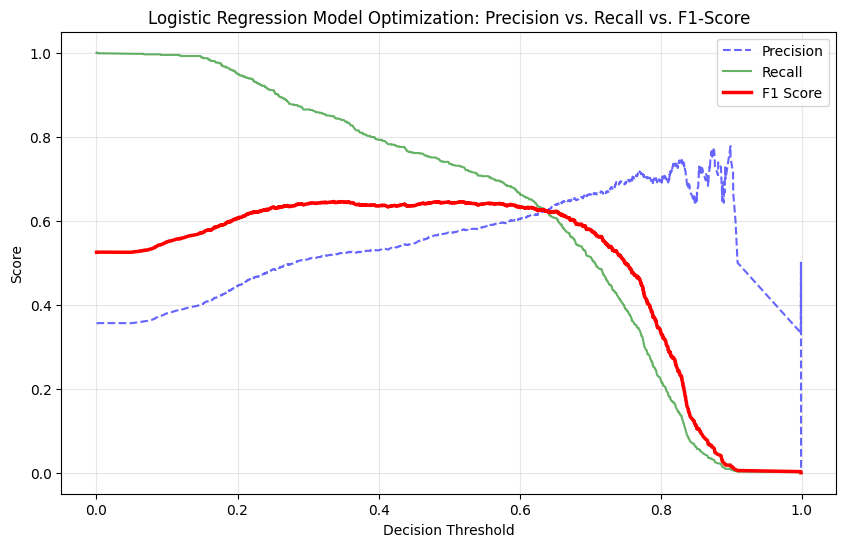

Optimal Threshold (F1-max): 0.3361


In [45]:
import numpy as np
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# 1. Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# 2. Calculate F1-Score for every threshold
# F1 = 2 * (precision * recall) / (precision + recall)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], "b--", label="Precision", alpha=0.6)
plt.plot(thresholds, recall[:-1], "g-", label="Recall", alpha=0.6)
plt.plot(thresholds, f1_scores, "r-", label="F1 Score", linewidth=2.5)

# 4. Formatting
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Logistic Regression Model Optimization: Precision vs. Recall vs. F1-Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

# Optional: Identify the exact threshold that maximizes F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal Threshold (F1-max): {best_threshold:.4f}")

**confusion matrix with optimal threshold**

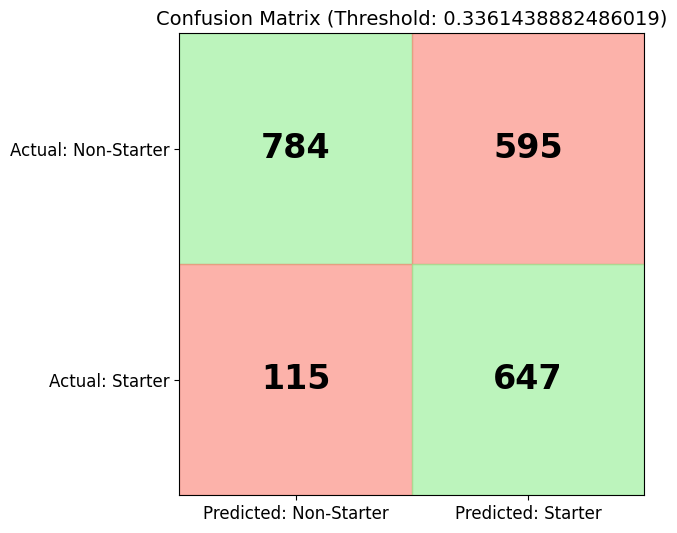

              precision    recall  f1-score   support

 Non-Starter       0.87      0.57      0.69      1379
     Starter       0.52      0.85      0.65       762

    accuracy                           0.67      2141
   macro avg       0.70      0.71      0.67      2141
weighted avg       0.75      0.67      0.67      2141



In [46]:
from sklearn.metrics import confusion_matrix, classification_report

# Applying optimal threshold
final_threshold = best_threshold

# Get predictions using the threshold
y_probs = log_model.predict_proba(X_test_scaled)[:, 1]
y_pred_final = (y_probs >= final_threshold).astype(int)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

# Setup the plot
fig, ax = plt.subplots(figsize=(6, 6))

# Define colors: Green for correct (TN=0,0 and TP=1,1), Red for errors (FP=0,1 and FN=1,0)
colors = [
    ['lightgreen', 'salmon'], # Row 0: TN, FP
    ['salmon', 'lightgreen']  # Row 1: FN, TP
]

# Create the grid and display the values
for i in range(2):
    for j in range(2):
        # Draw the rectangle background
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=colors[i][j], alpha=0.6))
        # Place the text
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=24, fontweight='bold')

# Correct axis settings
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(1.5, -0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Predicted: Non-Starter', 'Predicted: Starter'], fontsize=12)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Actual: Non-Starter', 'Actual: Starter'], fontsize=12)
ax.set_title(f"Confusion Matrix (Threshold: {final_threshold})", fontsize=14)
plt.grid(False)
plt.show()

# Print detailed metrics
print(classification_report(y_test, y_pred_final, target_names=["Non-Starter", "Starter"]))

**confustion matrix with default threshold**

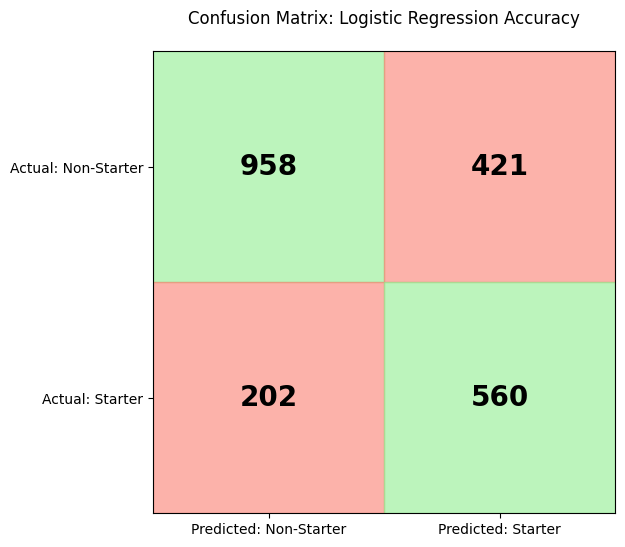

--- Detailed Classification Report ---
              precision    recall  f1-score   support

 Non-Starter       0.83      0.69      0.75      1379
     Starter       0.57      0.73      0.64       762

    accuracy                           0.71      2141
   macro avg       0.70      0.71      0.70      2141
weighted avg       0.74      0.71      0.71      2141



In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Predictions
y_pred = log_model.predict(X_test_scaled)

# Calculate confiusion matrix
cm = confusion_matrix(y_test, y_pred)

# Set up plot with colors
fig, ax = plt.subplots(figsize=(6, 6))

# Define your colors: Green for correct (TN, TP), Red for incorrect (FP, FN)
colors = [
    ['lightgreen', 'salmon'], # True Negative (G), False Positive (R)
    ['salmon', 'lightgreen']  # False Negative (R), True Positive (G)
]

# Create the background grid
ax.imshow(np.zeros((2, 2)), cmap='binary', alpha=0)

# Add the colored rectangles and text values
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=colors[i][j], alpha=0.6))
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=20, fontweight='bold')

# Labels and formatting
ax.set_xticks([0, 1])
ax.set_xticklabels(['Predicted: Non-Starter', 'Predicted: Starter'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Actual: Non-Starter', 'Actual: Starter'])
ax.set_title("Confusion Matrix: Logistic Regression Accuracy", pad=20)
plt.grid(False)
plt.show()

# Printing classification report
print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Non-Starter", "Starter"]))

**Looking at model coefficients and odds-ratios**

In [48]:
import numpy as np
import pandas as pd

# Identify columns to drop, consistent with how log_model was trained in o9TRxtTi8bcz
cols_to_drop_for_log_model = [
    "starter_by_year2", "name", "name_norm", "team", "hometown",
    "state", "city", "school", "player_id", "max_usage_first2yrs",
    "stars", "rating"
]

# Recreate X consistent with how log_model was trained
X_for_coef = data_allStats.drop(columns=['starter_by_year2'] + cols_to_drop_for_log_model, errors='ignore')
X_for_coef = pd.get_dummies(X_for_coef, drop_first=True)

# Get the coefficients from your trained model
coefficients = log_model.coef_[0]
features = X_for_coef.columns # Use the consistent feature set

# Create a DataFrame for readability
odds_ratios = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Odds Ratio': np.exp(coefficients)
})

# Sort by impact
odds_ratios = odds_ratios.sort_values(by='Odds Ratio', ascending=False)
print(odds_ratios)

                  Feature  Coefficient  Odds Ratio
22            position_QB     0.425398    1.530199
3             rating_diff     0.309693    1.363007
21           position_PRO     0.296983    1.345792
23            position_RB     0.253272    1.288234
41  conference_Unassigned     0.214488    1.239227
8           position_DUAL     0.166247    1.180864
13             position_K     0.136673    1.146453
15            position_LS     0.133528    1.142854
6             position_DL     0.099764    1.104910
36         conference_MAC     0.084888    1.088595
37         conference_MWC     0.078661    1.081838
32         conference_B1G     0.059434    1.061236
33        conference_CUSA     0.056288    1.057903
7             position_DT     0.056149    1.057756
19            position_OT     0.043774    1.044747
29         conference_ACC     0.036831    1.037517
12           position_IOL     0.031962    1.032478
25           position_SDE     0.030719    1.031195
14            position_LB     0

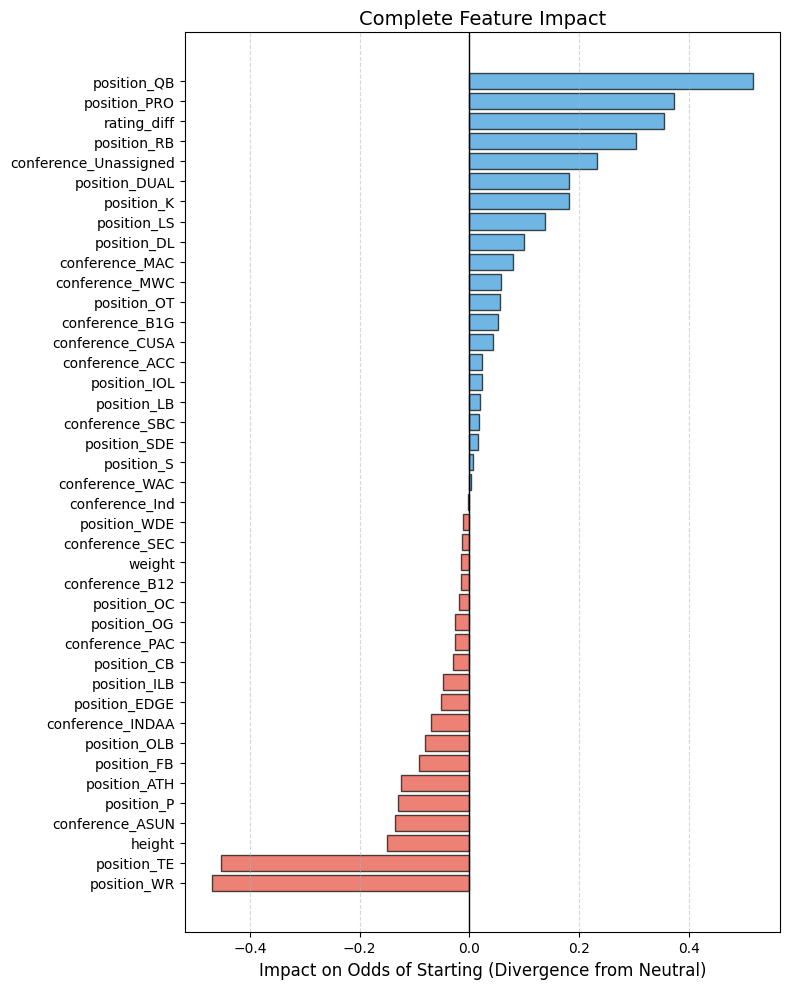

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

# Data set of features and odds ratios
data = {
    'Feature': [
        'position_QB', 'position_PRO', 'rating_diff', 'position_RB', 'conference_Unassigned',
        'position_DUAL', 'position_K', 'position_LS', 'position_DL', 'conference_MAC',
        'conference_MWC', 'position_OT', 'conference_B1G', 'conference_CUSA', 'conference_ACC',
        'position_IOL', 'position_LB', 'conference_SBC', 'position_SDE', 'position_S',
        'conference_WAC', 'conference_Ind', 'position_WDE', 'conference_SEC', 'weight',
        'conference_B12', 'position_OC', 'position_OG', 'conference_PAC', 'position_CB',
        'position_ILB', 'position_EDGE', 'conference_INDAA', 'position_OLB', 'position_FB',
        'position_ATH', 'position_P', 'conference_ASUN', 'height', 'position_TE', 'position_WR'
    ],
    'Odds Ratio': [
        1.516338, 1.372040, 1.354108, 1.304060, 1.232288, 1.181752, 1.181609, 1.137672,
        1.099933, 1.079882, 1.057976, 1.056349, 1.051173, 1.042567, 1.023255, 1.022284,
        1.019415, 1.017655, 1.015767, 1.006548, 1.002908, 0.996461, 0.988979, 0.985535,
        0.983888, 0.983822, 0.980985, 0.974322, 0.973627, 0.969629, 0.951381, 0.947571,
        0.930548, 0.919583, 0.907395, 0.875507, 0.869604, 0.864848, 0.849744, 0.547954,
        0.530448
    ]
}

df = pd.DataFrame(data)

# Calculating divergence factor
df['Divergence'] = df['Odds Ratio'] - 1
df = df.sort_values(by='Divergence', ascending=True)

# Plotting
plt.figure(figsize=(8,10))
colors = ['#e74c3c' if x < 0 else '#3498db' for x in df['Divergence']]

plt.barh(df['Feature'], df['Divergence'], color=colors, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.xlabel('Impact on Odds of Starting (Divergence from Neutral)', fontsize=12)
plt.title('Complete Feature Impact', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**filtering to statistically significant features:**

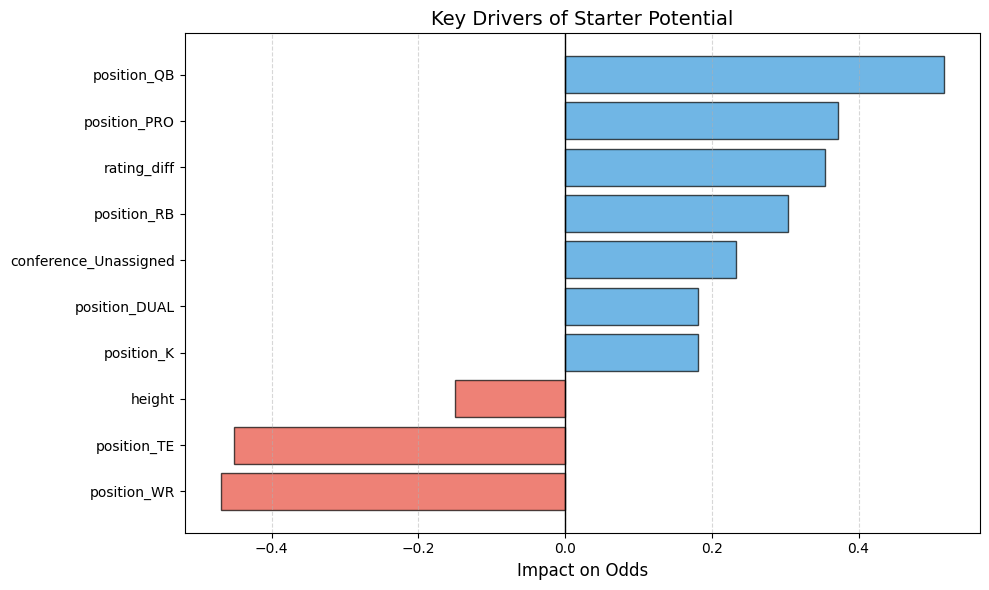

In [50]:
# Filtering to only keep features with absolute divergence > 0.15
significant_features = df[abs(df['Divergence']) > 0.15].sort_values(by='Divergence', ascending=True)

# Plotting
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x < 0 else '#3498db' for x in significant_features['Divergence']]
plt.barh(significant_features['Feature'], significant_features['Divergence'], color=colors, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.xlabel('Impact on Odds', fontsize=12)
plt.title('Key Drivers of Starter Potential', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Saving off model features for interactive tool:

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
joblib.dump(log_model, "/content/drive/MyDrive/CS 141/lr_starter_predictor.pkl")
joblib.dump(X.columns.tolist(), "/content/drive/MyDrive/CS 141/lr_model_features.pkl")

['/content/drive/MyDrive/CS 141/lr_model_features.pkl']

# **Random Forest Model:**

Test accuracy: 0.726
ROC AUC: 0.797


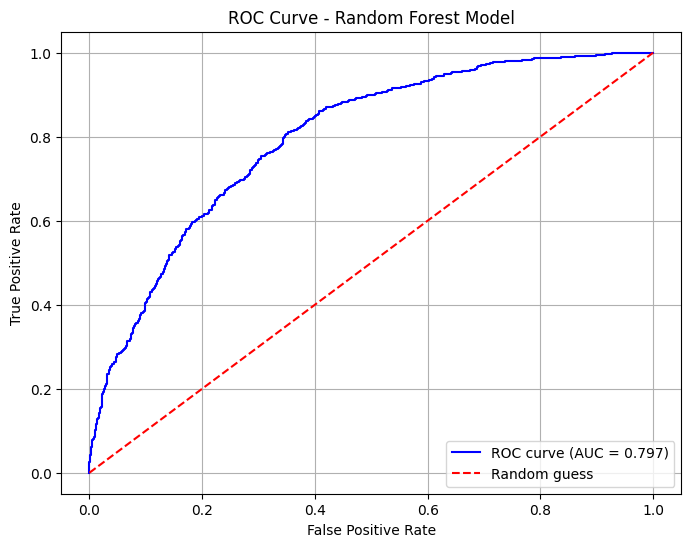

                  feature  importance
29            position_WR    0.130110
4             rating_diff    0.113432
3                  weight    0.113309
1                  rating    0.112997
2                  height    0.084792
0                    year    0.080131
27            position_TE    0.076427
24            position_RB    0.050734
22           position_PRO    0.043930
23            position_QB    0.041433
9           position_DUAL    0.019912
5            position_ATH    0.016591
42  conference_Unassigned    0.016119
30         conference_ACC    0.008137
40         conference_SBC    0.007847
41         conference_SEC    0.007660
32         conference_B12    0.007424
33         conference_B1G    0.007415
38         conference_MWC    0.007331
39         conference_PAC    0.006738


In [53]:
# -----------------------------
# Random Forest for Starter Prediction
# -----------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Prepare dataset
# -----------------------------
features = [
    "rating",
    "position",
    "height",
    "weight",
    "conference",
    "rating_diff"
]

# Drop any rows with missing target
model_df = data_allStats.dropna(subset=["starter_by_year2"]).copy()

# One-hot encode categorical variables
model_df = pd.get_dummies(model_df, columns=["position", "conference"], drop_first=True)

# Features and target
X = model_df[ [col for col in model_df.columns if col not in ["starter_by_year2", "stars", "name", "name_norm", "team", "player_id", "city", "state", "max_usage_first2yrs"]] ]
y = model_df["starter_by_year2"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Fit Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Test accuracy: {acc:.3f}")
print(f"ROC AUC: {roc_auc:.3f}")

# -----------------------------

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# Feature Importances
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(importances.head(20))

Random forest Grid Search:

In [54]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [500],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 8, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose = 2
)
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best Parameters: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 500}


Random Forest Permutation Importance:

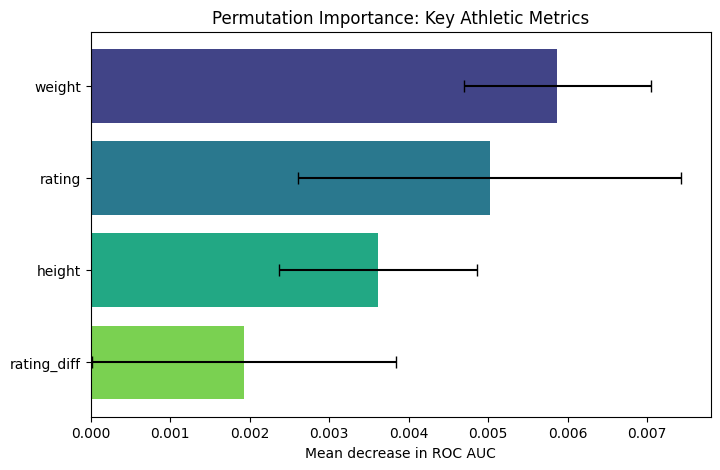

In [55]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Use the full test set (with all encoded columns)
X_test_full = pd.DataFrame(X_test, columns=X.columns)

# 2. Compute importance on the full dataset
perm_importance = permutation_importance(
    rf,
    X_test_full,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

# 3. Now, create your results DataFrame
perm_df = pd.DataFrame({
    "feature": X_test_full.columns, # All features
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
})

# 4. Filter for only your quantitative features for the plot
quant_features = ['height', 'weight', 'rating', 'rating_diff']
filtered_df = perm_df[perm_df['feature'].isin(quant_features)].sort_values("importance", ascending=False)

plt.figure(figsize=(8,5))

# Get the same viridis palette used by seaborn
colors = sns.color_palette("viridis", len(filtered_df))

plt.barh(
    filtered_df["feature"],
    filtered_df["importance"],
    xerr=filtered_df["std"],
    color=colors,
    capsize=4
)

plt.xlabel("Mean decrease in ROC AUC")
plt.title("Permutation Importance: Key Athletic Metrics")

plt.gca().invert_yaxis()

plt.show()

**Looking at precision/Recall tradeoff and optimal threshold**

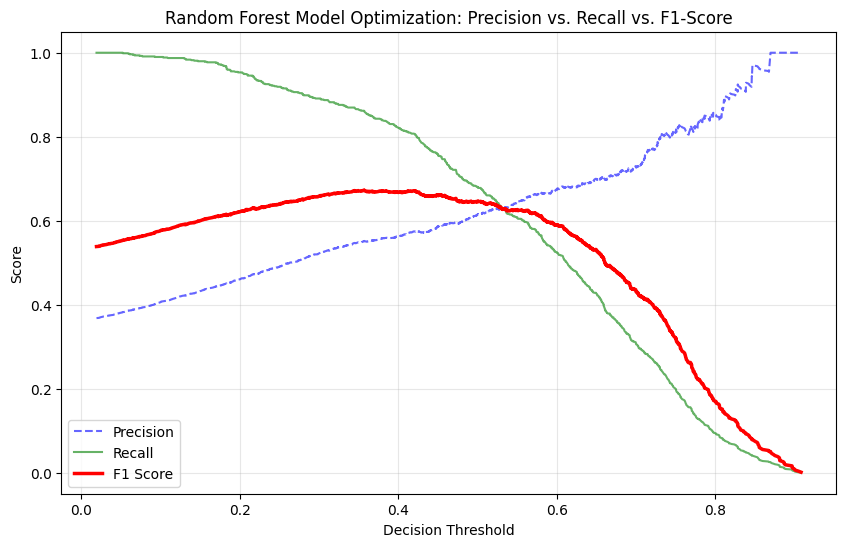

Optimal Threshold (F1-max): 0.3571


In [56]:
import numpy as np
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
y_probs = rf.predict_proba(X_test)[:, 1]
# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Calculate F1-Score for every threshold
# F1 = 2 * (precision * recall) / (precision + recall)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], "b--", label="Precision", alpha=0.6)
plt.plot(thresholds, recall[:-1], "g-", label="Recall", alpha=0.6)
plt.plot(thresholds, f1_scores, "r-", label="F1 Score", linewidth=2.5)

# Formatting
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Random Forest Model Optimization: Precision vs. Recall vs. F1-Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal Threshold (F1-max): {best_threshold:.4f}")

In [57]:
valid = (thresholds > 0.05) & (thresholds < 0.95)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
f1_scores = np.nan_to_num(f1_scores)

best_idx = np.argmax(f1_scores[valid])
best_threshold = thresholds[valid][best_idx]

print("Best threshold:", best_threshold)

Best threshold: 0.35710357200593595


In [58]:
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
best_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_idx]

print(f"Threshold for Max F1-Score: {best_f1_threshold:.4f}")

Threshold for Max F1-Score: 0.3571


**Random Forest Confusion Matrix with optimal threshold:**

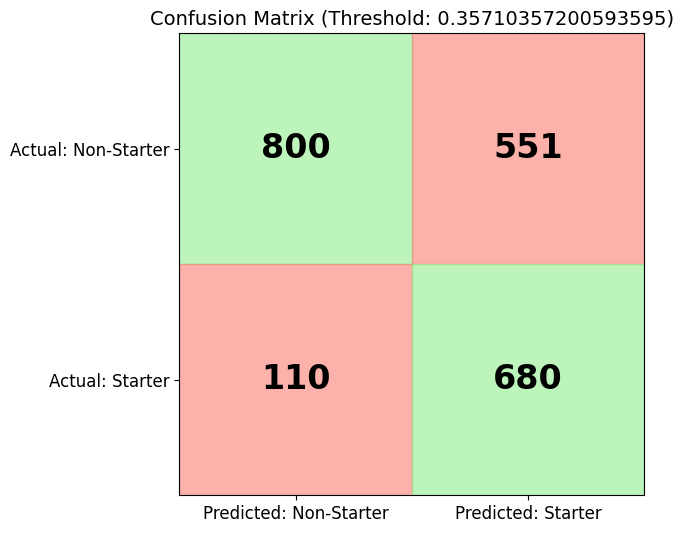

              precision    recall  f1-score   support

 Non-Starter       0.88      0.59      0.71      1351
     Starter       0.55      0.86      0.67       790

    accuracy                           0.69      2141
   macro avg       0.72      0.73      0.69      2141
weighted avg       0.76      0.69      0.69      2141



In [59]:
from sklearn.metrics import confusion_matrix, classification_report

# Applying optimal threshold
final_threshold = best_f1_threshold

# Get predictions using the threshold
y_probs = rf.predict_proba(X_test)[:, 1]
y_pred_final = (y_probs >= final_threshold).astype(int)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

# Setup the plot
fig, ax = plt.subplots(figsize=(6, 6))

# Define colors: Green for correct (TN=0,0 and TP=1,1), Red for errors (FP=0,1 and FN=1,0)
colors = [
    ['lightgreen', 'salmon'], # Row 0: TN, FP
    ['salmon', 'lightgreen']  # Row 1: FN, TP
]

# Create the grid and display the values
for i in range(2):
    for j in range(2):
        # Draw the rectangle background
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=colors[i][j], alpha=0.6))
        # Place the text
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=24, fontweight='bold')

# Correct axis settings
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(1.5, -0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Predicted: Non-Starter', 'Predicted: Starter'], fontsize=12)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Actual: Non-Starter', 'Actual: Starter'], fontsize=12)
ax.set_title(f"Confusion Matrix (Threshold: {final_threshold})", fontsize=14)
plt.grid(False)
plt.show()

# Print detailed metrics
print(classification_report(y_test, y_pred_final, target_names=["Non-Starter", "Starter"]))


**Random Forest Confusion Matrix with deafult threshold:**

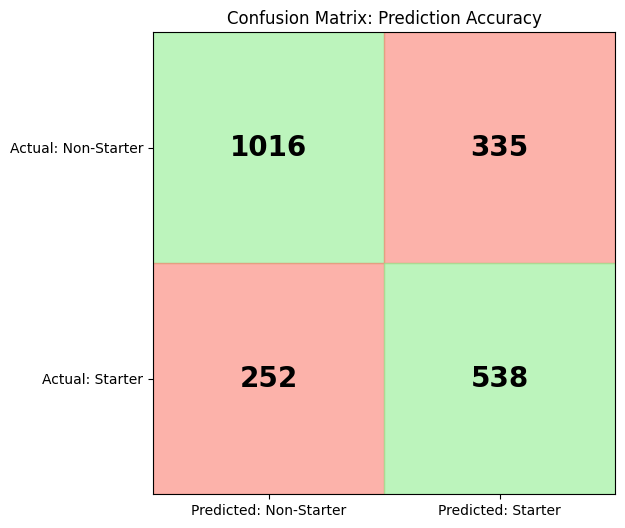

              precision    recall  f1-score   support

 Non-Starter       0.80      0.75      0.78      1351
     Starter       0.62      0.68      0.65       790

    accuracy                           0.73      2141
   macro avg       0.71      0.72      0.71      2141
weighted avg       0.73      0.73      0.73      2141



In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
# cm is typically: [[TN, FP], [FN, TP]]

# 2. Setup the plot
fig, ax = plt.subplots(figsize=(6, 6))

# Define colors: Green for correct (TN, TP), Red for incorrect (FP, FN)
# TN at [0,0], FP at [0,1], FN at [1,0], TP at [1,1]
colors = [
    ['lightgreen', 'salmon'], # TN (Green), FP (Red)
    ['salmon', 'lightgreen']  # FN (Red), TP (Green)
]

# Create the grid
ax.imshow(np.zeros((2, 2)), cmap='binary', alpha=0) # Hidden base

# Add the colored rectangles
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=colors[i][j], alpha=0.6))
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=20, fontweight='bold')

# Labels and formatting
ax.set_xticks([0, 1])
ax.set_xticklabels(['Predicted: Non-Starter', 'Predicted: Starter'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Actual: Non-Starter', 'Actual: Starter'])
ax.set_title("Confusion Matrix: Prediction Accuracy")
plt.grid(False)
plt.show()

# 4. Print detailed metrics for deeper analysis
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=["Non-Starter", "Starter"]))

**SHAP stuff:**

  0%|          | 0/500 [00:00<?, ?it/s]

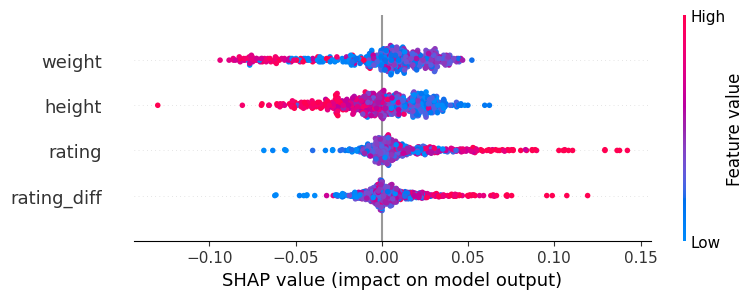

In [61]:
import shap
import numpy as np

# Using a small sample to ensure KernelExplainer runs
X_test_sample = X_test.sample(n=500, random_state=42)

# Background dataset for KernelExplainer
# using the mean of the training data as a reference point
background = shap.kmeans(X_train, 10)

# Initialize the KernelExplainer
explainer = shap.KernelExplainer(rf.predict_proba, background)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_sample, nsamples=100)

# Getting SHAP values for the starter class
shap_values_starter = shap_values[:, :, 1]

# Plotting for quantitative features
shap_df = pd.DataFrame(shap_values_starter, columns=X.columns)
plot_data = shap_df[['rating', 'height', 'weight', 'rating_diff']]

shap.summary_plot(plot_data.values, X_test_sample[['rating', 'height', 'weight', 'rating_diff']])

**Looking at tipping points for rating and rating_diff**

In [62]:
import numpy as np

# Column indices
rating_diff_idx = X_test_sample.columns.get_loc('rating_diff')
rating_idx = X_test_sample.columns.get_loc('rating')

# Find neutral SHAP points for rating_diff
neutral_points_rd = X_test_sample['rating_diff'][
    np.abs(shap_values_starter[:, rating_diff_idx]) < 0.05
]

tipping_point_rd = neutral_points_rd.mean()

print(f"The model's projected 'Starter' tipping point for rating_diff is: {tipping_point_rd:.4f}")


# Find neutral SHAP points for rating
neutral_points_r = X_test_sample['rating'][
    np.abs(shap_values_starter[:, rating_idx]) < 0.05
]

tipping_point_r = neutral_points_r.mean()

print(f"The model's projected 'Starter' tipping point for rating is: {tipping_point_r:.4f}")

The model's projected 'Starter' tipping point for rating_diff is: -0.0025
The model's projected 'Starter' tipping point for rating is: 0.8413


Saving off model features for interactive tool:

In [63]:
joblib.dump(rf, "/content/drive/MyDrive/CS 141/rf_starter_predictor.pkl")
joblib.dump(X.columns.tolist(), "/content/drive/MyDrive/CS 141/rf_model_features.pkl")

['/content/drive/MyDrive/CS 141/rf_model_features.pkl']

# **XGBoost Model**

In [64]:
# -----------------------------
# XGBoost for Starter Prediction
# -----------------------------
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report
import pandas as pd
import matplotlib.pyplot as plt


# Prepare dataset
model_df = data_allStats.dropna(subset=["starter_by_year2"]).copy()

# One-hot encode categorical variables
model_df = pd.get_dummies(model_df, columns=["position", "conference"], drop_first=True)

# Features and target
X = model_df[ [col for col in model_df.columns if col not in ["starter_by_year2", "name", "name_norm", "team", "player_id", "city", "state", "max_usage_first2yrs", "stars"]] ]
y = model_df["starter_by_year2"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Fit XGBoost Model
# Calculate scale_pos_weight to handle class imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    scale_pos_weight=neg_count / pos_count, # Weighting the starters higher
    subsample=0.7,      # Prevents overfitting
    colsample_bytree=0.7,
    random_state=42,
    early_stopping_rounds=50
)
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Test accuracy: {acc:.3f}")
print(f"ROC AUC: {roc_auc:.3f}")


Test accuracy: 0.719
ROC AUC: 0.804


In [65]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# 1. Define a smaller parameter grid for speed
param_dist = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

# Calculate scale_pos_weight to handle class imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

# Set up the Randomized Search
# n_iter=10 means it will only test 10 random combinations
random_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(scale_pos_weight=neg_count/pos_count, random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    n_jobs=-1, # Uses all CPU cores
    cv=3,      # 3-fold cross-validation
    verbose=1,
    random_state=42
)

# Fit the search
random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best ROC AUC: {random_search.best_score_:.3f}")

# Use the best model
best_xgb = random_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best ROC AUC: 0.793


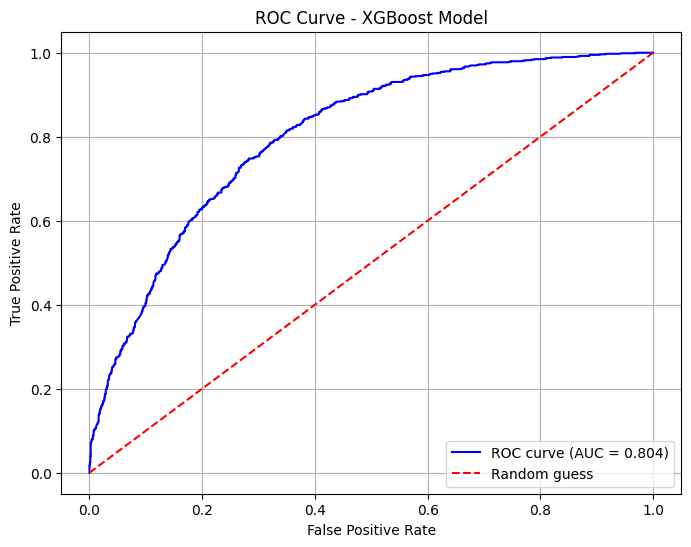

                  feature  importance
27            position_TE    0.172209
29            position_WR    0.171614
24            position_RB    0.125076
22           position_PRO    0.084484
23            position_QB    0.060714
5            position_ATH    0.052071
9           position_DUAL    0.043601
0                    year    0.025926
19           position_OLB    0.021276
42  conference_Unassigned    0.018491
1                  rating    0.017751
12           position_ILB    0.017271
4             rating_diff    0.016684
3                  weight    0.016601
15            position_LB    0.016116
2                  height    0.015945
6             position_CB    0.014915
11            position_FB    0.014773
40         conference_SBC    0.013155
39         conference_PAC    0.012934


In [66]:
# -----------------------------
# ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# -----------------------------
# Feature Importances
# -----------------------------
# XGBoost provides feature_importances_ based on the weight of features
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importances.head(20))

**Permutation importance**

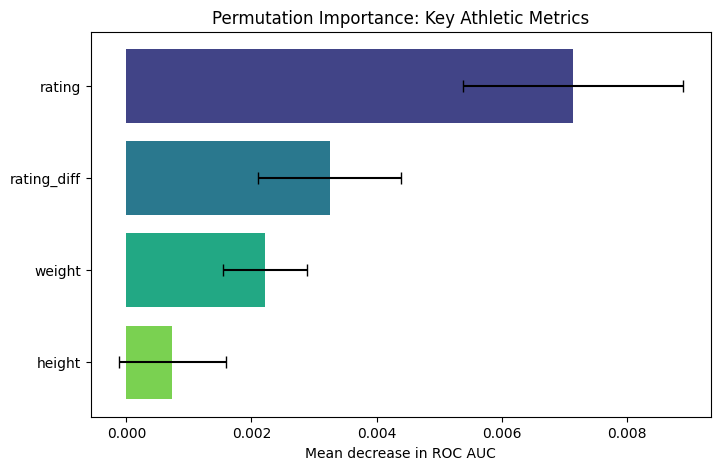

In [67]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Use the full test set (with all encoded columns)
X_test_full = pd.DataFrame(X_test, columns=X.columns)

# 2. Compute importance on the full dataset
perm_importance = permutation_importance(
    xgb_model,
    X_test_full,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

# 3. Now, create your results DataFrame
perm_df = pd.DataFrame({
    "feature": X_test_full.columns, # All features
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
})

# 4. Filter for only your quantitative features for the plot
quant_features = ['height', 'weight', 'rating', 'rating_diff']
filtered_df = perm_df[perm_df['feature'].isin(quant_features)].sort_values("importance", ascending=False)

plt.figure(figsize=(8,5))

# Get the same viridis palette used by seaborn
colors = sns.color_palette("viridis", len(filtered_df))

plt.barh(
    filtered_df["feature"],
    filtered_df["importance"],
    xerr=filtered_df["std"],
    color=colors,
    capsize=4
)

plt.xlabel("Mean decrease in ROC AUC")
plt.title("Permutation Importance: Key Athletic Metrics")

plt.gca().invert_yaxis()

plt.show()

**Looking at tradeoff between Precision and Recall and optimal threshold:**

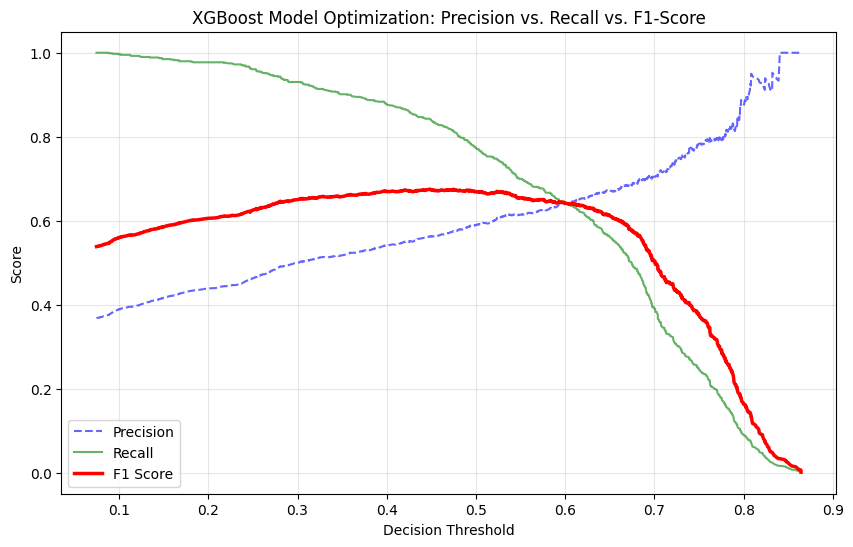

Optimal Threshold (F1-max): 0.4481


In [68]:
import numpy as np
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
y_probs = xgb_model.predict_proba(X_test)[:, 1]
# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Calculate F1-Score for every threshold
# F1 = 2 * (precision * recall) / (precision + recall)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], "b--", label="Precision", alpha=0.6)
plt.plot(thresholds, recall[:-1], "g-", label="Recall", alpha=0.6)
plt.plot(thresholds, f1_scores, "r-", label="F1 Score", linewidth=2.5)

# Formatting
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("XGBoost Model Optimization: Precision vs. Recall vs. F1-Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()


best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal Threshold (F1-max): {best_threshold:.4f}")

In [69]:
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
best_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_idx]

print(f"Threshold for Max F1-Score: {best_f1_threshold:.4f}")

Threshold for Max F1-Score: 0.4481


**XGBoost Confusion Matrix with optimal threshold:**

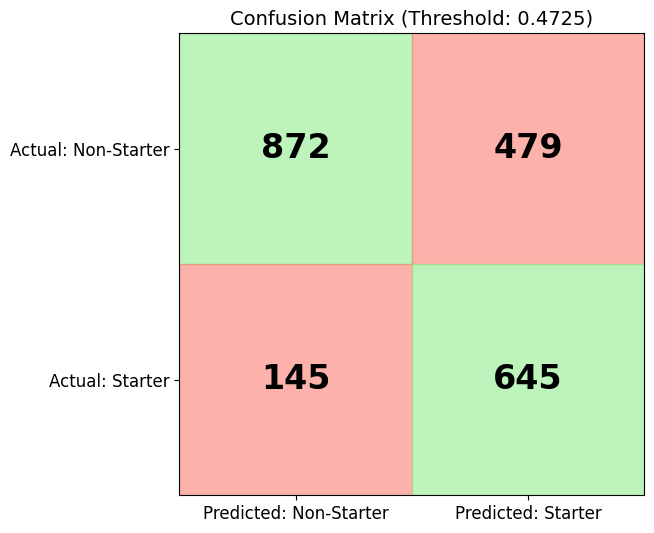

              precision    recall  f1-score   support

 Non-Starter       0.86      0.65      0.74      1351
     Starter       0.57      0.82      0.67       790

    accuracy                           0.71      2141
   macro avg       0.72      0.73      0.71      2141
weighted avg       0.75      0.71      0.71      2141



In [70]:
from sklearn.metrics import confusion_matrix, classification_report

# Applying optimal threshold
final_threshold = 0.4725

# Get predictions using the threshold
y_probs = xgb_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_probs >= final_threshold).astype(int)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

# Setup the plot
fig, ax = plt.subplots(figsize=(6, 6))

# Define colors: Green for correct (TN=0,0 and TP=1,1), Red for errors (FP=0,1 and FN=1,0)
colors = [
    ['lightgreen', 'salmon'], # Row 0: TN, FP
    ['salmon', 'lightgreen']  # Row 1: FN, TP
]

# Create the grid and display the values
for i in range(2):
    for j in range(2):
        # Draw the rectangle background
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=colors[i][j], alpha=0.6))
        # Place the text
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=24, fontweight='bold')

# Correct axis settings
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(1.5, -0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Predicted: Non-Starter', 'Predicted: Starter'], fontsize=12)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Actual: Non-Starter', 'Actual: Starter'], fontsize=12)
ax.set_title(f"Confusion Matrix (Threshold: {final_threshold})", fontsize=14)
plt.grid(False)
plt.show()

# Print detailed metrics
print(classification_report(y_test, y_pred_final, target_names=["Non-Starter", "Starter"]))

**XGBoost Confusion Matrix with deafult threshold:**

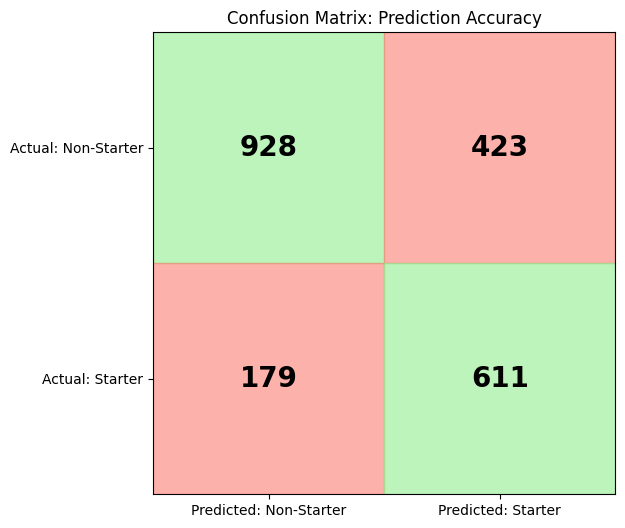

              precision    recall  f1-score   support

 Non-Starter       0.84      0.69      0.76      1351
     Starter       0.59      0.77      0.67       790

    accuracy                           0.72      2141
   macro avg       0.71      0.73      0.71      2141
weighted avg       0.75      0.72      0.72      2141



In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# -----------------------------
# Evaluate
# -----------------------------

# 1. Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
# cm is typically: [[TN, FP], [FN, TP]]

# 2. Setup the plot
fig, ax = plt.subplots(figsize=(6, 6))

# Define colors: Green for correct (TN, TP), Red for incorrect (FP, FN)
# TN at [0,0], FP at [0,1], FN at [1,0], TP at [1,1]
colors = [
    ['lightgreen', 'salmon'], # TN (Green), FP (Red)
    ['salmon', 'lightgreen']  # FN (Red), TP (Green)
]

# Create the grid
ax.imshow(np.zeros((2, 2)), cmap='binary', alpha=0) # Hidden base

# Add the colored rectangles
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=colors[i][j], alpha=0.6))
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=20, fontweight='bold')

# Labels and formatting
ax.set_xticks([0, 1])
ax.set_xticklabels(['Predicted: Non-Starter', 'Predicted: Starter'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Actual: Non-Starter', 'Actual: Starter'])
ax.set_title("Confusion Matrix: Prediction Accuracy")
plt.grid(False)
plt.show()

# 4. Print detailed metrics for deeper analysis
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=["Non-Starter", "Starter"]))

In [72]:
joblib.dump(xgb_model, "/content/drive/MyDrive/CS 141/xgb_starter_predictor.pkl")
joblib.dump(X.columns.tolist(), "/content/drive/MyDrive/CS 141/xgb_model_features.pkl")

['/content/drive/MyDrive/CS 141/xgb_model_features.pkl']

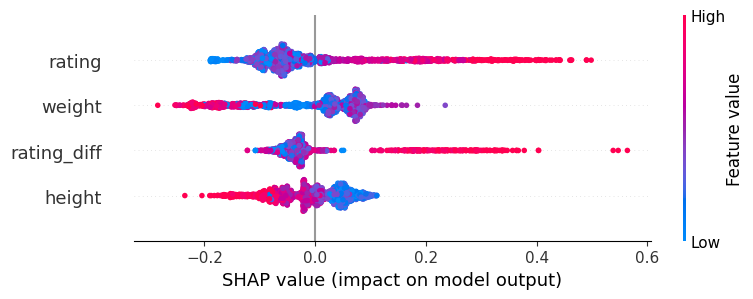

In [73]:
import shap

# Use the full test set (X_test) so the model sees all features it expects
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Identify which columns you want to plot
quant_features = ['rating', 'height', 'weight', 'rating_diff']

# Assuming X_test.columns is a list of all features in order
# Find the indices of your quantitative features
indices = [X_test.columns.get_loc(c) for c in quant_features]

# Slice the shap_values array to keep only those columns
# The shape of shap_values is (n_samples, n_features)
filtered_shap_values = shap_values[:, indices]

# Plot using the filtered values and filtered feature names
shap.summary_plot(filtered_shap_values, X_test[quant_features])

**Looking at tipping points for rating and rating_diff**

In [74]:
import numpy as np

# This finds the 'rating_diff' value where the model's SHAP impact is exactly 0
# (i.e., the transition from "unlikely" to "likely" to start)
# We can estimate this by finding the mean of 'rating_diff' where the SHAP value is near zero
neutral_points_rd = X_test['rating_diff'][np.abs(shap_values[:, X_test.columns.get_loc('rating_diff')]) < 0.05]
tipping_point_rd = neutral_points_rd.mean()

print(f"The model's projected 'Starter' tipping point for rating_diff is: {tipping_point_rd:.4f}")

neutral_points_r = X_test['rating'][np.abs(shap_values[:, X_test.columns.get_loc('rating')]) < 0.05]
tipping_point_r = neutral_points_r.mean()

print(f"The model's projected 'Starter' tipping point for rating is: {tipping_point_r:.4f}")


The model's projected 'Starter' tipping point for rating_diff is: -0.0116
The model's projected 'Starter' tipping point for rating is: 0.8342


Seeing how similar XGBoost and Random forest are - they are pretty much the same

In [75]:
# Get the predicted probabilities for the "Starter" class (column 1)
rf_probs = rf.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Calculate the correlation between their predictions
correlation = np.corrcoef(rf_probs, xgb_probs)[0, 1]
print(f"Correlation between RF and XGBoost predictions: {correlation:.4f}")

Correlation between RF and XGBoost predictions: 0.9656


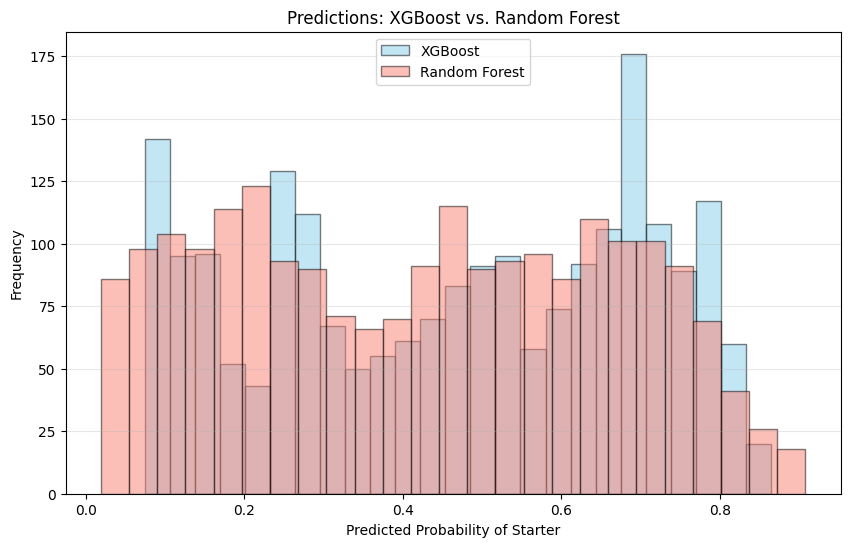

In [76]:
# Get probabilities for both models
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]

# Setup the plot
plt.figure(figsize=(10, 6))

# Plot XGBoost
plt.hist(xgb_probs, bins=25, color='skyblue', alpha=0.5, label='XGBoost', edgecolor='black')

# Plot Random Forest
plt.hist(rf_probs, bins=25, color='salmon', alpha=0.5, label='Random Forest', edgecolor='black')


# Formatting
plt.title('Predictions: XGBoost vs. Random Forest')
plt.xlabel('Predicted Probability of Starter')
plt.ylabel('Frequency')
plt.legend(loc='upper center')
plt.grid(axis='y', alpha=0.3)

plt.show()

# **Stacking Classifier**

In [77]:
# -----------------------------
# Stacking Classifier for Starter Prediction
# -----------------------------
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, f1_score
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Prepare dataset (same as your RF setup)
# -----------------------------
model_df = data_allStats.dropna(subset=["starter_by_year2"]).copy()

model_df = pd.get_dummies(model_df, columns=["position", "conference"], drop_first=True)

# Same exclusion logic we used in RF
X = model_df[[col for col in model_df.columns if col not in [
    "starter_by_year2", "stars", "name", "name_norm", "team",
    "player_id", "city", "state", "max_usage_first2yrs"
]]]
y = model_df["starter_by_year2"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Impute missing values (stacking requires clean input for all base models)
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# -----------------------------
# Define base models (our existing three)
# -----------------------------
base_models = [
    ("lr", Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ])),
    ("rf", RandomForestClassifier(
        n_estimators=1000,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    )),
    ("xgb", XGBClassifier(
        n_estimators=1000,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # mirrors class_weight balanced
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    )),
]

# -----------------------------
# Meta-learner: simple LR on top
# -----------------------------
meta_learner = LogisticRegression(class_weight="balanced", random_state=42)

# -----------------------------
# Build stacking classifier
# -----------------------------
stack = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,                    # 5-fold CV to generate meta-features (prevents leakage)
    stack_method="predict_proba",  # passes probabilities to meta-learner, not hard labels
    passthrough=False        # set True if we want raw features passed to meta-learner too
)

stack.fit(X_train_imp, y_train)

# -----------------------------
# Evaluate
# -----------------------------
y_pred       = stack.predict(X_test_imp)
y_pred_proba = stack.predict_proba(X_test_imp)[:, 1]

acc     = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1      = f1_score(y_test, y_pred)

print(f"Stacking — Accuracy: {acc:.3f}  |  ROC AUC: {roc_auc:.3f}  |  F1: {f1:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["Non-Starter", "Starter"]))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:43:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:44:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:44:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:44:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Stacking — Accuracy: 0.714  |  ROC AUC: 0.802  |  F1: 0.660

              precision    recall  f1-score   support

 Non-Starter       0.83      0.69      0.75      1351
     Starter       0.59      0.75      0.66       790

    accuracy                           0.71      2141
   macro avg       0.71      0.72      0.71      2141
weighted avg       0.74      0.71      0.72      2141



In [78]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_thresh = thresholds[f1_scores.argmax()]
print(f"Best threshold: {best_thresh:.3f}")

y_pred_tuned = (y_pred_proba >= best_thresh).astype(int)  # re-classify using hte best threshold
print(classification_report(y_test, y_pred_tuned, target_names=["Non-Starter", "Starter"]))

Best threshold: 0.412
              precision    recall  f1-score   support

 Non-Starter       0.87      0.62      0.73      1351
     Starter       0.57      0.84      0.68       790

    accuracy                           0.70      2141
   macro avg       0.72      0.73      0.70      2141
weighted avg       0.76      0.70      0.71      2141



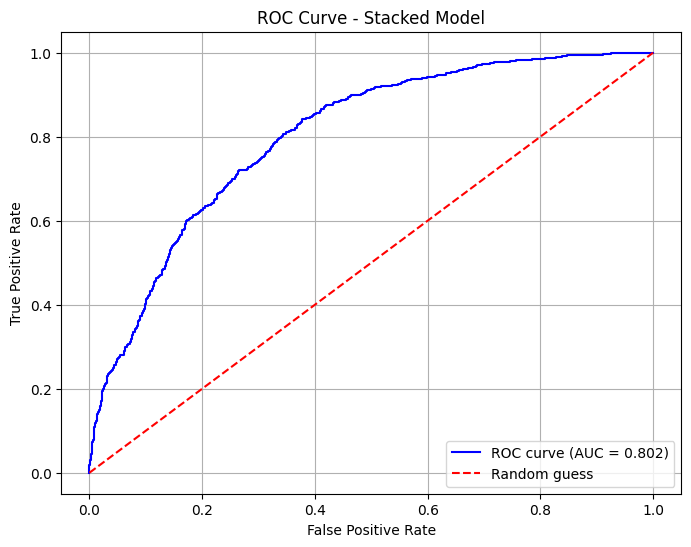

In [79]:
# -----------------------------
# ROC Curve - Stacked Model
# -----------------------------
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacked Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


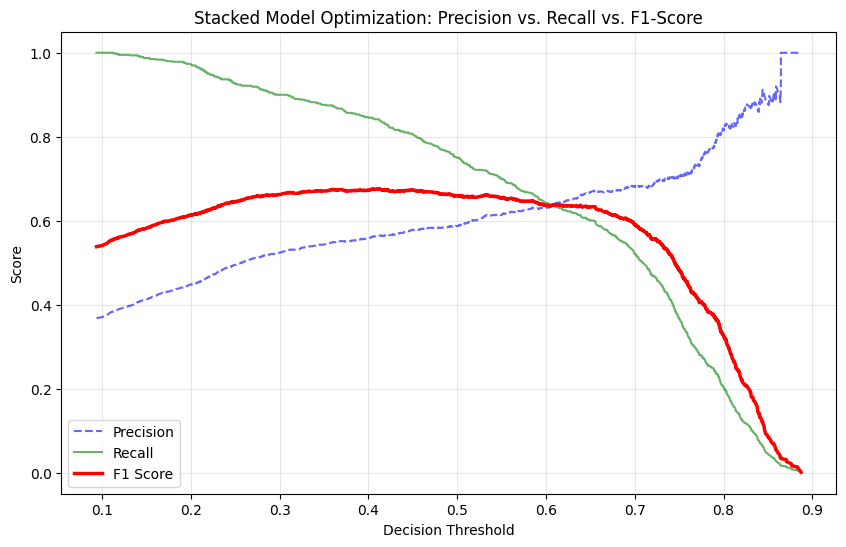

Optimal Threshold (F1-max): 0.4117


In [80]:
# -----------------------------
# Precision-Recall Threshold Curve - Stacked Model
# -----------------------------
y_probs = stack.predict_proba(X_test)[:, 1]
# 1. Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# 2. Calculate F1-Score for every threshold
# F1 = 2 * (precision * recall) / (precision + recall)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], "b--", label="Precision", alpha=0.6)
plt.plot(thresholds, recall[:-1], "g-", label="Recall", alpha=0.6)
plt.plot(thresholds, f1_scores, "r-", label="F1 Score", linewidth=2.5)

# 4. Formatting
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Stacked Model Optimization: Precision vs. Recall vs. F1-Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

# Optional: Identify the exact threshold that maximizes F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal Threshold (F1-max): {best_threshold:.4f}")

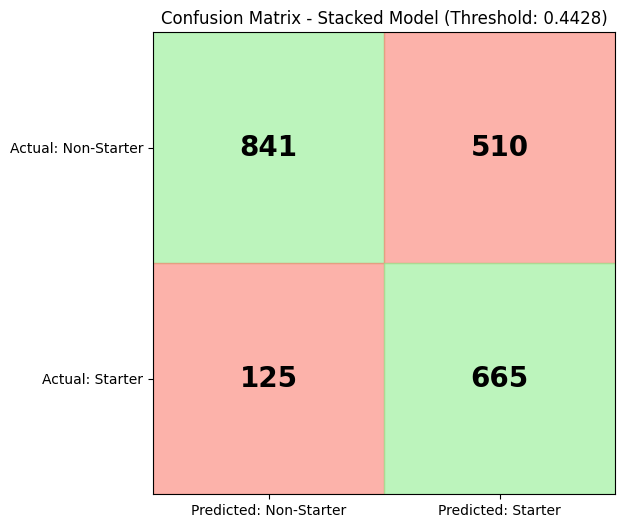

              precision    recall  f1-score   support

 Non-Starter       0.87      0.62      0.73      1351
     Starter       0.57      0.84      0.68       790

    accuracy                           0.70      2141
   macro avg       0.72      0.73      0.70      2141
weighted avg       0.76      0.70      0.71      2141



In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# -----------------------------
# Confusion Matrix - Stacked Model
# -----------------------------
cm = confusion_matrix(y_test, y_pred_tuned)  # use y_pred_tuned since you threshold-tuned

fig, ax = plt.subplots(figsize=(6, 6))

colors = [
    ['lightgreen', 'salmon'],
    ['salmon', 'lightgreen']
]

ax.imshow(np.zeros((2, 2)), cmap='binary', alpha=0)

for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=colors[i][j], alpha=0.6))
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=20, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Predicted: Non-Starter', 'Predicted: Starter'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Actual: Non-Starter', 'Actual: Starter'])
ax.set_title("Confusion Matrix - Stacked Model (Threshold: 0.4428)")
plt.grid(False)
plt.show()

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_tuned, target_names=["Non-Starter", "Starter"]))

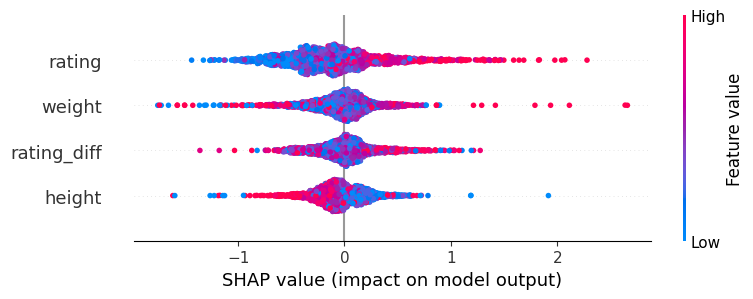

In [82]:
import shap

# -----------------------------
# SHAP Value Plot - Stacked Model
# -----------------------------
xgb_inside_stack = stack.named_estimators_['xgb']

explainer = shap.TreeExplainer(xgb_inside_stack)
shap_values = explainer.shap_values(X_test_imp)

quant_features = ['rating', 'height', 'weight', 'rating_diff']

indices = [list(X_test.columns).index(c) for c in quant_features]

filtered_shap_values = shap_values[:, indices]
shap.summary_plot(filtered_shap_values, X_test[quant_features])